# CSE440 Lab Project - Multi-Class Text Classification

This notebook is revised to follow the **Lab 1 to Lab 4 flow** more closely while still completing the full project requirements from the project brief.

What is included:
- **EDA** with graphs and word clouds
- **three preprocessing versions**: raw, extreme, optimum
- **TF-IDF** with **one ML model** and **one Deep Neural Network**
- **Skip-gram** with **SimpleRNN, GRU, LSTM, Bidirectional SimpleRNN, Bidirectional GRU, Bidirectional LSTM**
- **different hyperparameters** across preprocessing versions and models
- **saved histories, checkpoints, reports, confusion matrices, and one experiment history table**
- **cached preprocessing files** so reruns can skip repeated work

This keeps the implementation simple, avoids optional items, and keeps the notebook organized like an extension of the lab notebooks.


## 1. Module Import

The notebook uses the same overall course flow as the labs:
- **Lab 1** style EDA and preprocessing
- **Lab 2** style word representations
- **Lab 3** style ML and Deep NN structure
- **Lab 4** style sequence model grouping

The neural models are kept in **PyTorch** with **CUDA-first training** so the notebook can use GPU acceleration when available, while still running on CPU if CUDA is not available.

In [64]:
import os
import re
import json
import html
import math
import time
import copy
import pickle
import random
import warnings
from pathlib import Path
from contextlib import nullcontext

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display
from wordcloud import WordCloud
from gensim.models import Word2Vec

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from nltk.stem import PorterStemmer

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (10, 5)
sns.set_theme(style="whitegrid")


SEED = 440
VAL_SIZE = 0.15
DEFAULT_PATIENCE = 2
NUM_WORKERS = 0 if os.name == "nt" else min(4, os.cpu_count() or 2)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_CUDA = DEVICE.type == "cuda"
USE_AMP = USE_CUDA
PIN_MEMORY = USE_CUDA

if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")

def set_seed(seed: int = SEED) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if hasattr(torch.backends, "cudnn"):
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(SEED)
print("Device:", DEVICE)
print("Seed:", SEED)
print("CUDA available:", torch.cuda.is_available())
print("AMP enabled:", USE_AMP)
print("DataLoader workers:", NUM_WORKERS)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


def find_project_dir() -> Path:
    candidate_dirs = [
        Path.cwd(),
        Path.cwd().parent,
        Path("/mnt/data/cse440_project_artifacts"),
        Path("/mnt/data"),
    ]

    for candidate in candidate_dirs:
        if (candidate / "processed_data").exists():
            return candidate

    for candidate in candidate_dirs:
        if (candidate / "Training_data_4.csv").exists():
            return candidate

    return Path.cwd()

def find_file(filename: str) -> Path:
    candidates = [
        Path.cwd() / filename,
        Path.cwd().parent / filename,
        Path("/mnt/data") / filename,
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(f"Could not find {filename}")

TRAIN_PATH = find_file("Training_data_4.csv")
TEST_PATH = find_file("Test_data.csv")

PROJECT_DIR = find_project_dir()
PROCESSED_DIR = PROJECT_DIR / "processed_data"
VECTORIZER_DIR = PROJECT_DIR / "vectorizers"
WORD2VEC_DIR = PROJECT_DIR / "word2vec_models_pytorch_cuda"
CHECKPOINT_DIR = PROJECT_DIR / "checkpoints_pytorch_cuda"
HISTORY_DIR = PROJECT_DIR / "histories_pytorch_cuda"
REPORT_DIR = PROJECT_DIR / "reports_pytorch_cuda"
PLOT_DIR = PROJECT_DIR / "plots_pytorch_cuda"
RESULT_DIR = PROJECT_DIR / "results_pytorch_cuda"
SPLIT_DIR = PROJECT_DIR / "split_cache"

for folder in [
    PROCESSED_DIR,
    VECTORIZER_DIR,
    WORD2VEC_DIR,
    CHECKPOINT_DIR,
    HISTORY_DIR,
    REPORT_DIR,
    PLOT_DIR,
    RESULT_DIR,
    SPLIT_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Training file:", TRAIN_PATH)
print("Testing file:", TEST_PATH)
print("Processed cache:", PROCESSED_DIR)
print("PyTorch/CUDA results directory:", RESULT_DIR)

Device: cuda
Seed: 440
CUDA available: True
AMP enabled: True
DataLoader workers: 0
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
Project directory: f:\Coding\Projects\440 proj\mnt\data\cse440_project_artifacts_pytorch_cuda
Training file: f:\Coding\Projects\440 proj\mnt\data\cse440_project_artifacts_pytorch_cuda\Training_data_4.csv
Testing file: f:\Coding\Projects\440 proj\mnt\data\cse440_project_artifacts_pytorch_cuda\Test_data.csv
Processed cache: f:\Coding\Projects\440 proj\mnt\data\cse440_project_artifacts_pytorch_cuda\processed_data
PyTorch/CUDA results directory: f:\Coding\Projects\440 proj\mnt\data\cse440_project_artifacts_pytorch_cuda\results_pytorch_cuda


## 2. Load Dataset

The train split is used for training and validation.  
The given test split is kept only for the final evaluation, matching the project instructions.

In [65]:
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

assert {"News Headline", "News Topic"}.issubset(train_df.columns)
assert {"News Headline", "News Topic"}.issubset(test_df.columns)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
display(train_df.head())
display(train_df["News Topic"].value_counts())

print(train_df.isna().sum())
print(test_df.isna().sum())

Train shape: (104763, 2)
Test shape: (12000, 2)


,News Headline,News Topic
0,<html> <body> News Headlines:\r\n <br> <b> Hug...,World News
1,<html> <body> News Headlines:\r\n <br> <b> Mic...,Science and Technology
2,<html> <body> News Headlines:\r\n <br> <b> Gor...,Science and Technology
3,<html> <body> News Headlines:\r\n <br> <b> U.S...,Business
4,<html> <body> News Headlines:\r\n <br> <b> Non...,Business


News Topic
Science and Technology    36428
Sports                    34178
Business                  18563
World News                15594
Name: count, dtype: int64

News Headline    0
News Topic       0
dtype: int64
News Headline    0
News Topic       0
dtype: int64


## 3. Exploratory Data Analysis

This section follows the basic style of **Lab 1**:
- inspect the dataset
- examine class balance
- inspect headline lengths
- create word clouds
- use the observations to justify the preprocessing choices

Sample cleaned headlines:
- News Headlines: Huge boost to Darfur aid effort The World Food Programme is starting to airlift almost 100 more tons of food a day to Sudan's troubled Darfur region. ...
- News Headlines: Microsoft Revises Anti-Spam Standard (Reuters) Reuters - Microsoft Corp. on Monday\said it had revised its proposal to weed out "spam" e-mail to\win over skeptical  ...
- News Headlines: Gordon Cooper, 1 of 1st astronauts VENTURA, Calif. - Gordon Cooper, who as one of the original Mercury astronauts was a pioneer in human space exploration, has died ...


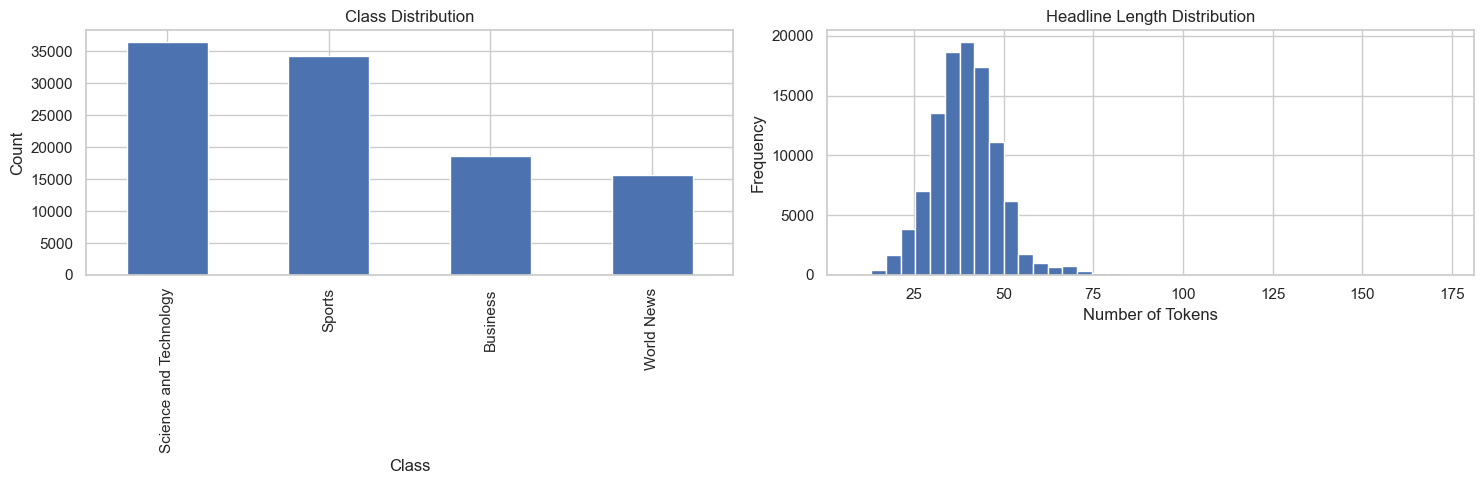

count    104763.000000
mean         39.626213
std          10.361447
min           9.000000
25%          33.000000
50%          39.000000
75%          45.000000
max         173.000000
Name: News Headline, dtype: float64

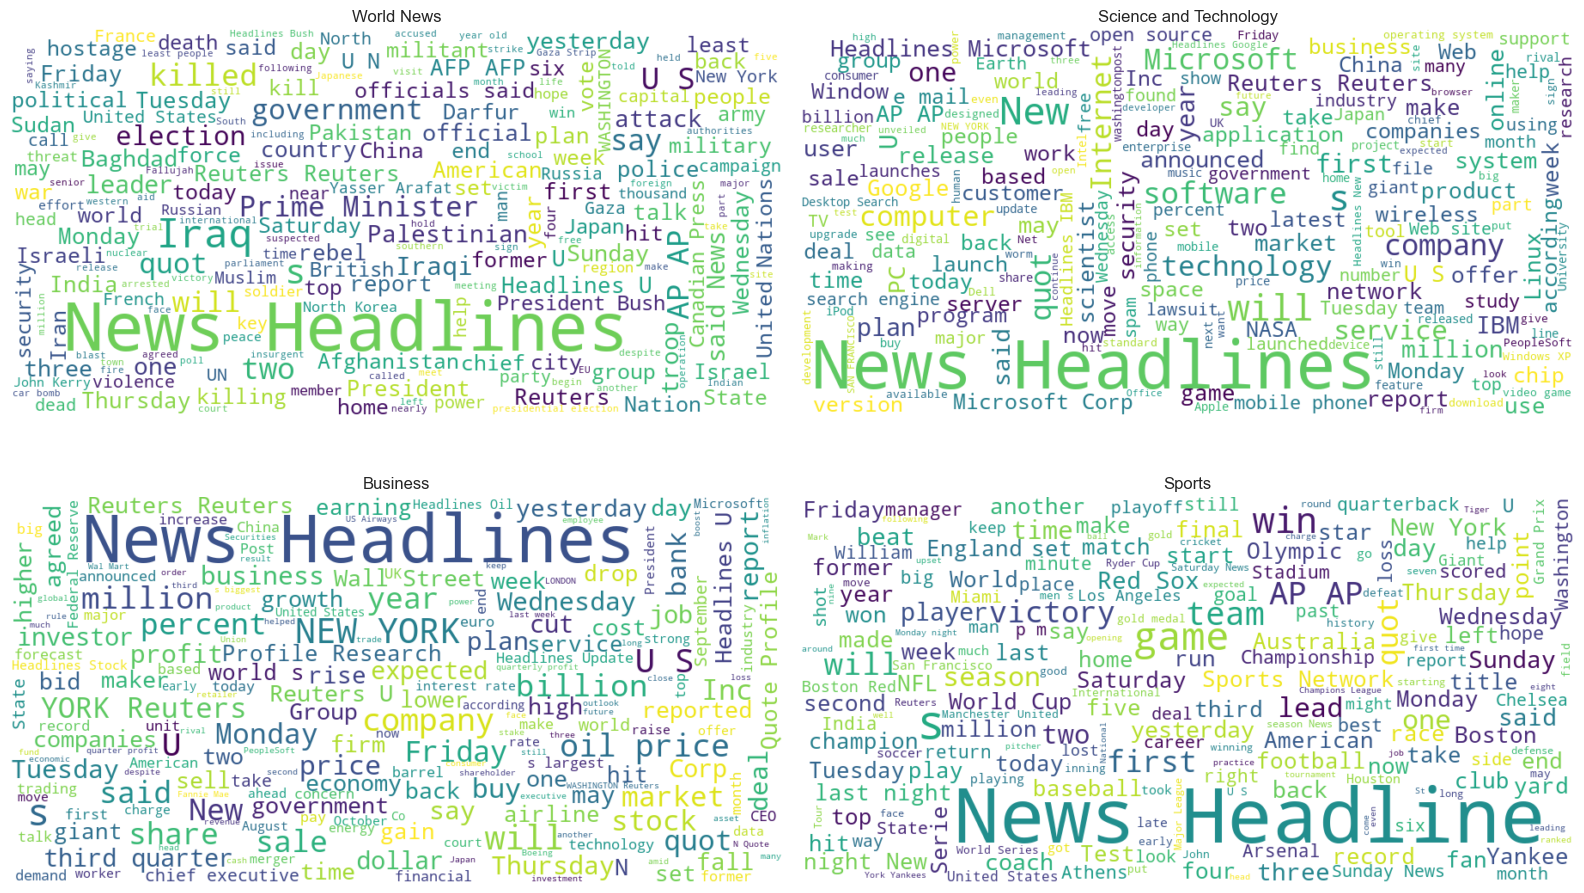

,headline_length_words,alpha_token_count
count,104763.000000,104763.000000
mean,39.626213,39.525395
std,10.361447,10.387981
min,9.000000,9.000000
25%,33.000000,33.000000
50%,39.000000,39.000000
75%,45.000000,44.000000
max,173.000000,177.000000


,News Topic,percentage
0,Science and Technology,34.77
1,Sports,32.62
2,Business,17.72
3,World News,14.89


In [66]:
TAG_RE = re.compile(r"<[^>]+>")
URL_RE = re.compile(r"https?://\S+|www\.\S+")
SPACE_RE = re.compile(r"\s+")

def strip_html_text(text: str) -> str:
    text = html.unescape(str(text))
    text = text.replace("\\r", " ").replace("\\n", " ")
    text = TAG_RE.sub(" ", text)
    text = text.replace("\r", " ").replace("\n", " ")
    text = URL_RE.sub(" ", text)
    text = SPACE_RE.sub(" ", text).strip()
    return text

eda_text = train_df["News Headline"].map(strip_html_text)
headline_lengths = eda_text.str.split().str.len()

print("Sample cleaned headlines:")
for row in eda_text.head(3):
    print("-", row[:180], "...")


fig, ax = plt.subplots(1, 2, figsize=(15, 5))

train_df["News Topic"].value_counts().plot(kind="bar", ax=ax[0], title="Class Distribution")
ax[0].set_xlabel("Class")
ax[0].set_ylabel("Count")

ax[1].hist(headline_lengths, bins=40)
ax[1].set_title("Headline Length Distribution")
ax[1].set_xlabel("Number of Tokens")
ax[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

display(headline_lengths.describe())


topics = train_df["News Topic"].unique().tolist()
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, topic in enumerate(topics):
    topic_text = " ".join(
        eda_text[train_df["News Topic"] == topic].head(2500).tolist()
    )
    wordcloud = WordCloud(
        width=900,
        height=450,
        background_color="white"
    ).generate(topic_text)
    axes[idx].imshow(wordcloud, interpolation="bilinear")
    axes[idx].set_title(topic)
    axes[idx].axis("off")

plt.tight_layout()
plt.show()


clean_token_counts = eda_text.str.lower().str.findall(r"[a-z]+").map(len)
eda_summary = pd.DataFrame({
    "headline_length_words": headline_lengths.describe(),
    "alpha_token_count": clean_token_counts.describe(),
})
display(eda_summary)

topic_share = (
    train_df["News Topic"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename("percentage")
    .reset_index()
)
display(topic_share)

### 3.1 Dataset Overview and Raw Inspection

In [67]:
overview_df = pd.DataFrame({
    "split": ["train", "test"],
    "rows": [len(train_df), len(test_df)],
    "missing_text": [train_df["News Headline"].isna().sum(), test_df["News Headline"].isna().sum()],
    "missing_label": [train_df["News Topic"].isna().sum(), test_df["News Topic"].isna().sum()],
    "unique_raw_texts": [train_df["News Headline"].nunique(), test_df["News Headline"].nunique()],
    "duplicate_rows": [train_df.duplicated().sum(), test_df.duplicated().sum()]
})
display(overview_df)

sample_view = train_df.sample(5, random_state=SEED)[["News Topic", "News Headline"]]
display(sample_view)

,split,rows,missing_text,missing_label,unique_raw_texts,duplicate_rows
0,train,104763,0,0,73555,31208
1,test,12000,0,0,12000,0


,News Topic,News Headline
87691,Business,<html> <body> News Headlines:\r\n <br> <b> A F...
26534,Science and Technology,<html> <body> News Headlines:\r\n <br> <b> Are...
101306,Science and Technology,<html> <body> News Headlines:\r\n <br> <b> Goo...
38401,Science and Technology,<html> <body> News Headlines:\r\n <br> <b> Nin...
85631,Science and Technology,<html> <body> News Headlines:\r\n <br> <b> All...


### 3.2 Cleaning Helpers for EDA Artifacts

In [68]:
ENTITY_REPLACEMENTS = {
    r"#39;": "'",
    r"#146;": "'",
    r"quot;": '"',
    r"amp;": "&",
    r"#151;": "-",
    r"#36;": "$",
    r"&lt;": "<",
    r"&gt;": ">"
}

def normalize_artifacts(text):
    text = str(text)
    for pattern, replacement in ENTITY_REPLACEMENTS.items():
        text = re.sub(pattern, replacement, text)
    text = text.replace("\\", " ")
    return text

def basic_eda_clean(text):
    text = normalize_artifacts(text)
    text = html.unescape(text)
    text = TAG_RE.sub(" ", text)
    text = re.sub(r"^\s*News Headlines:\s*", "", text, flags=re.I)
    text = SPACE_RE.sub(" ", text).strip()
    return text

for df in [train_df, test_df]:
    df["text_eda"] = df["News Headline"].apply(basic_eda_clean)
    df["char_len"] = df["text_eda"].str.len()
    df["word_len"] = df["text_eda"].str.count(r"\b\w+\b")
    df["has_digit"] = df["text_eda"].str.contains(r"\d", regex=True)
    df["has_parentheses"] = df["text_eda"].str.contains(r"[()]", regex=True)
    df["has_hyphen"] = df["text_eda"].str.contains(r"-", regex=True)
    df["has_quote"] = df["text_eda"].str.contains(r"['\"]", regex=True)
    df["has_backslash"] = df["News Headline"].astype(str).str.contains(r"\\", regex=True)
    df["has_html_tags"] = df["News Headline"].astype(str).str.contains(r"<html>|<body>|<br>|<b>", regex=True)
    df["has_broken_entities"] = df["News Headline"].astype(str).str.contains(r"#39;|quot;|amp;|#151;|#36;|&lt;|&gt;", regex=True)
    df["starts_with_news_headlines"] = df["News Headline"].astype(str).str.contains("News Headlines:", regex=False)

display(train_df[["News Topic", "text_eda"]].head())

,News Topic,text_eda
0,World News,Huge boost to Darfur aid effort The World Food...
1,Science and Technology,Microsoft Revises Anti-Spam Standard (Reuters)...
2,Science and Technology,"Gordon Cooper, 1 of 1st astronauts VENTURA, Ca..."
3,Business,U.S. Trade Deficit Swells to Record $55.5B (AP...
4,Business,Nonunion firms hit ironworkers with suit Six N...


### 3.3 Data-Quality Summary

In [69]:
quality_df = pd.DataFrame({
    "metric": [
        "rows",
        "missing_text",
        "missing_label",
        "unique_raw_texts",
        "duplicate_rows",
        "avg_words",
        "median_words",
        "avg_chars",
        "median_chars",
        "has_html_tags_pct",
        "has_broken_entities_pct",
        "has_backslash_pct",
        "starts_with_news_headlines_pct"
    ],
    "train": [
        len(train_df),
        train_df["News Headline"].isna().sum(),
        train_df["News Topic"].isna().sum(),
        train_df["News Headline"].nunique(),
        train_df.duplicated().sum(),
        round(train_df["word_len"].mean(), 2),
        int(train_df["word_len"].median()),
        round(train_df["char_len"].mean(), 2),
        int(train_df["char_len"].median()),
        round(train_df["has_html_tags"].mean() * 100, 2),
        round(train_df["has_broken_entities"].mean() * 100, 2),
        round(train_df["has_backslash"].mean() * 100, 2),
        round(train_df["starts_with_news_headlines"].mean() * 100, 2)
    ],
    "test": [
        len(test_df),
        test_df["News Headline"].isna().sum(),
        test_df["News Topic"].isna().sum(),
        test_df["News Headline"].nunique(),
        test_df.duplicated().sum(),
        round(test_df["word_len"].mean(), 2),
        int(test_df["word_len"].median()),
        round(test_df["char_len"].mean(), 2),
        int(test_df["char_len"].median()),
        round(test_df["has_html_tags"].mean() * 100, 2),
        round(test_df["has_broken_entities"].mean() * 100, 2),
        round(test_df["has_backslash"].mean() * 100, 2),
        round(test_df["starts_with_news_headlines"].mean() * 100, 2)
    ]
})
display(quality_df)

,metric,train,test
0,rows,104763.00,12000.00
1,missing_text,0.00,0.00
2,missing_label,0.00,0.00
3,unique_raw_texts,73555.00,12000.00
4,duplicate_rows,31208.00,0.00
5,avg_words,38.38,38.46
6,median_words,38.00,38.00
7,avg_chars,229.41,230.70
8,median_chars,226.00,229.00
9,has_html_tags_pct,100.00,100.00


### 3.4 Duplicate Analysis

,News Topic,total,dup_rows,repeated_beyond_first,dup_row_pct,unique_texts
0,Business,18563,0,0,0.00,18563
1,Science and Technology,36428,27010,16424,74.15,20004
2,Sports,34178,24543,14784,71.81,19394
3,World News,15594,0,0,0.00,15594


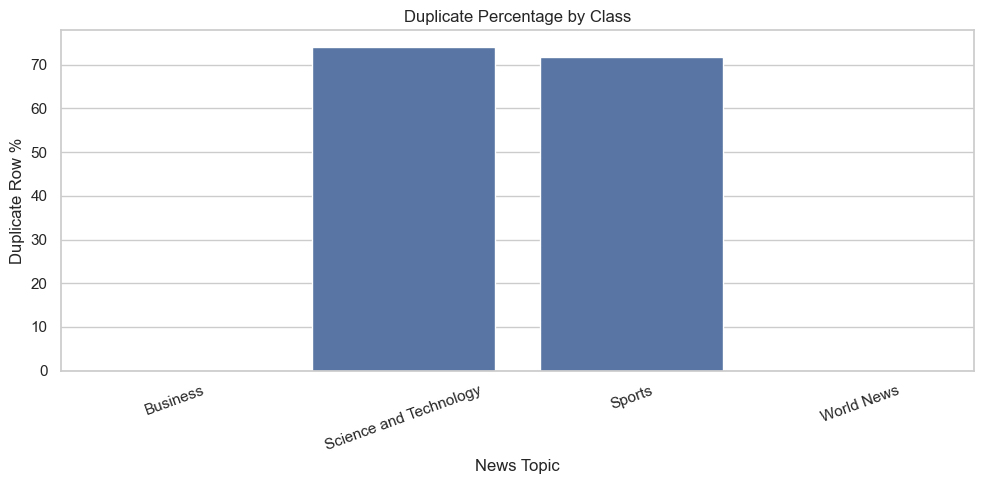

In [70]:
dup_df = train_df.assign(dup_any=train_df["News Headline"].duplicated(keep=False)).groupby("News Topic").agg(
    total=("News Headline", "size"),
    dup_rows=("dup_any", "sum"),
    repeated_beyond_first=("News Headline", lambda s: int(s.duplicated().sum()))
).reset_index()

dup_df["dup_row_pct"] = (dup_df["dup_rows"] / dup_df["total"] * 100).round(2)
dup_df["unique_texts"] = dup_df["total"] - dup_df["repeated_beyond_first"]

display(dup_df)

plt.figure(figsize=(10, 5))
sns.barplot(data=dup_df, x="News Topic", y="dup_row_pct")
plt.title("Duplicate Percentage by Class")
plt.xlabel("News Topic")
plt.ylabel("Duplicate Row %")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### 3.5 Length and Class-wise Statistics

,News Topic,count,avg_words,median_words,avg_chars,median_chars,digits_pct,parentheses_pct,hyphen_pct,quote_pct,broken_entities_pct
0,Business,18563,38.29,38.0,230.75,232.0,50.90,36.20,60.22,42.28,38.35
1,Science and Technology,36428,38.05,37.0,231.59,227.0,38.61,28.55,59.73,43.69,28.65
2,Sports,34178,38.36,37.0,221.59,216.0,52.49,25.26,67.10,48.02,35.79
3,World News,15594,39.34,39.0,239.88,240.0,34.27,34.14,63.11,46.10,25.04


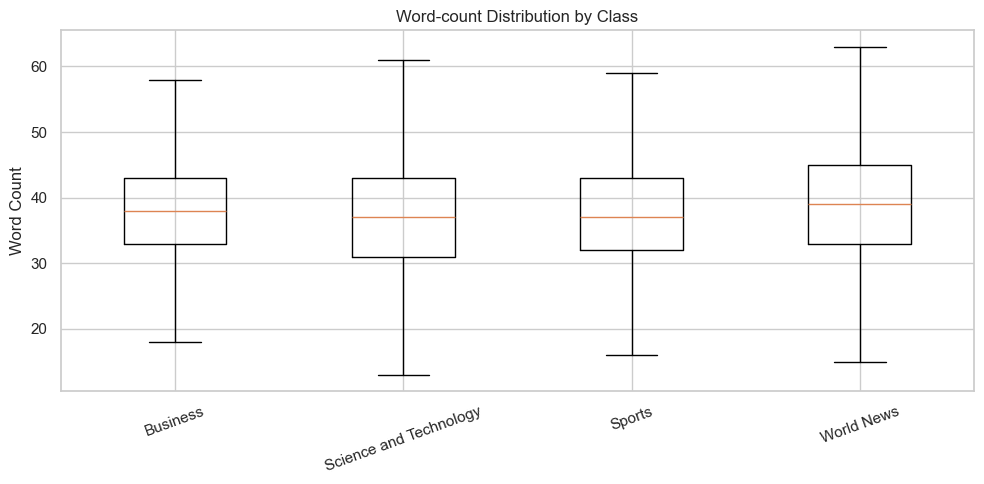

In [71]:
length_stats_df = train_df.groupby("News Topic").agg(
    count=("text_eda", "size"),
    avg_words=("word_len", "mean"),
    median_words=("word_len", "median"),
    avg_chars=("char_len", "mean"),
    median_chars=("char_len", "median"),
    digits_pct=("has_digit", "mean"),
    parentheses_pct=("has_parentheses", "mean"),
    hyphen_pct=("has_hyphen", "mean"),
    quote_pct=("has_quote", "mean"),
    broken_entities_pct=("has_broken_entities", "mean")
).reset_index()

for col in length_stats_df.columns:
    if col.endswith("_pct"):
        length_stats_df[col] = (length_stats_df[col] * 100).round(2)
    elif col not in ["News Topic", "count"]:
        length_stats_df[col] = length_stats_df[col].round(2)

display(length_stats_df)

plt.figure(figsize=(10, 5))
ordered_topics = sorted(train_df["News Topic"].unique())
box_data = [train_df.loc[train_df["News Topic"] == topic, "word_len"] for topic in ordered_topics]
plt.boxplot(box_data, labels=ordered_topics, showfliers=False)
plt.title("Word-count Distribution by Class")
plt.ylabel("Word Count")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### 3.6 Source-tag Frequency by Class

,News Topic,Reuters_pct,AP_pct,AFP_pct
0,Business,18.90,0.93,1.09
1,Science and Technology,6.68,6.88,0.68
2,Sports,4.67,10.35,0.51
3,World News,13.10,10.35,6.16


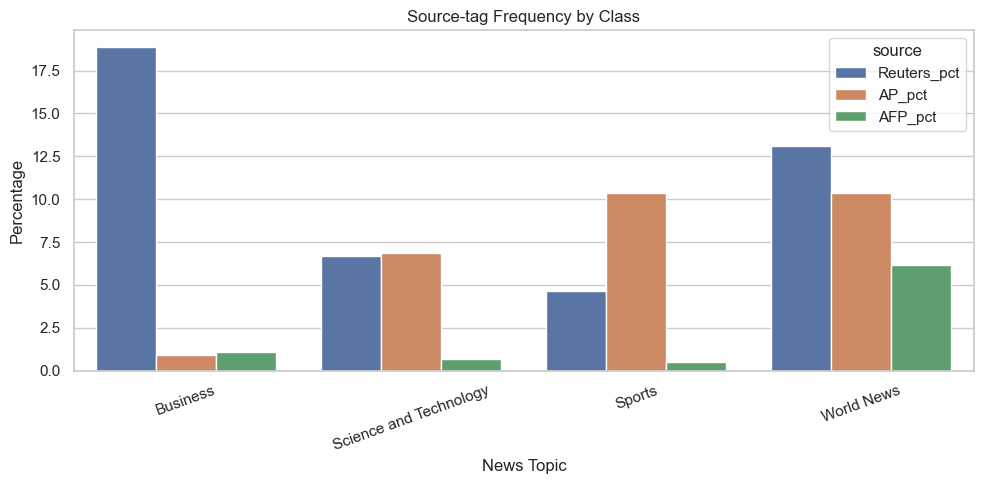

In [72]:
source_df = []
for topic, subset in train_df.groupby("News Topic"):
    source_df.append({
        "News Topic": topic,
        "Reuters_pct": round(subset["text_eda"].str.contains(r"\bReuters\b", regex=True).mean() * 100, 2),
        "AP_pct": round(subset["text_eda"].str.contains(r"\bAP\b", regex=True).mean() * 100, 2),
        "AFP_pct": round(subset["text_eda"].str.contains(r"\bAFP\b", regex=True).mean() * 100, 2)
    })

source_df = pd.DataFrame(source_df)
display(source_df)

source_plot_df = source_df.melt(id_vars="News Topic", var_name="source", value_name="pct")

plt.figure(figsize=(10, 5))
sns.barplot(data=source_plot_df, x="News Topic", y="pct", hue="source")
plt.title("Source-tag Frequency by Class")
plt.xlabel("News Topic")
plt.ylabel("Percentage")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### 3.7 Most Common Unigrams and Bigrams by Class

In [73]:
from sklearn.feature_extraction.text import CountVectorizer

def remove_source_tags(text):
    text = re.sub(r"\((Reuters|AP|AFP)\)", " ", text)
    text = re.sub(r"\b(?:Reuters|AP|AFP)\b\s*[-:)]?", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_df["text_no_source"] = train_df["text_eda"].apply(remove_source_tags)

def get_top_ngrams(texts, ngram_range=(1, 1), top_n=12):
    vectorizer = CountVectorizer(lowercase=True, stop_words="english", ngram_range=ngram_range, min_df=5)
    matrix = vectorizer.fit_transform(texts)
    counts = np.asarray(matrix.sum(axis=0)).ravel()
    terms = np.array(vectorizer.get_feature_names_out())
    order = counts.argsort()[::-1][:top_n]
    return pd.DataFrame({"term": terms[order], "count": counts[order]})

top_unigrams = {
    topic: get_top_ngrams(group["text_no_source"], (1, 1), 12)
    for topic, group in train_df.groupby("News Topic")
}

top_bigrams = {
    topic: get_top_ngrams(group["text_no_source"], (2, 2), 12)
    for topic, group in train_df.groupby("News Topic")
}

for topic in sorted(train_df["News Topic"].unique()):
    print(f"\nTop unigrams - {topic}")
    display(top_unigrams[topic])

for topic in sorted(train_df["News Topic"].unique()):
    print(f"\nTop bigrams - {topic}")
    display(top_bigrams[topic])


Top unigrams - Business


,term,count
0,said,4521
1,new,4152
2,oil,3911
3,company,2678
4,prices,2602
5,percent,2162
6,york,2137
7,year,2062
8,corp,1909
9,million,1808



Top unigrams - Science and Technology


,term,count
0,new,8660
1,microsoft,6231
2,said,4622
3,software,4400
4,internet,4158
5,company,3578
6,space,3262
7,search,2828
8,security,2756
9,web,2649



Top unigrams - Sports


...

,term,count
0,open source,1045
1,microsoft corp,877
2,search engine,756
3,mobile phone,628
4,san francisco,599
5,windows xp,593
6,washingtonpost com,555
7,new york,551
8,video game,543
9,said tuesday,542



Top bigrams - Sports


,term,count
0,new york,1911
1,red sox,1673
2,sports network,1461
3,world cup,1016
4,united states,637
5,gold medal,625
6,manchester united,619
7,los angeles,578
8,champions league,570
9,ryder cup,566



Top bigrams - World News


,term,count
0,prime minister,1216
1,officials said,482
2,united states,467
3,president bush,452
4,canadian press,451
5,united nations,449
6,yasser arafat,381
7,new york,351
8,john kerry,316
9,north korea,299


### 3.8 Per-class Top Words Plots

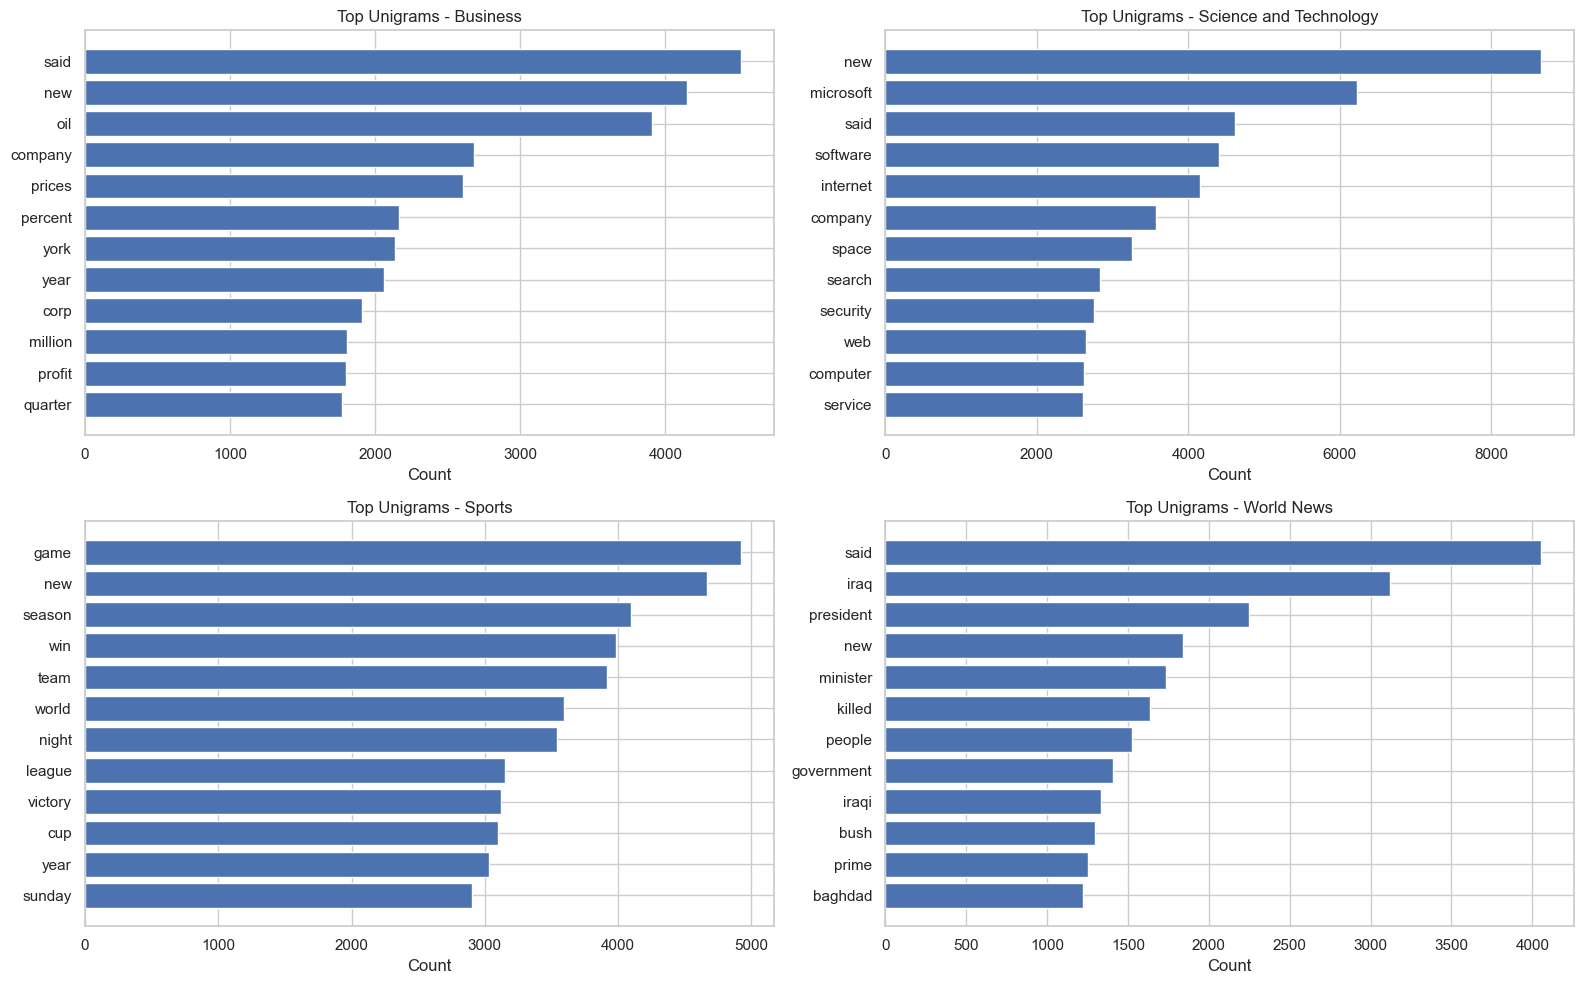

In [74]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, topic in zip(axes, sorted(train_df["News Topic"].unique())):
    plot_df = top_unigrams[topic].sort_values("count")
    ax.barh(plot_df["term"], plot_df["count"])
    ax.set_title(f"Top Unigrams - {topic}")
    ax.set_xlabel("Count")

plt.tight_layout()
plt.show()

## 4. Preprocessing

The project requires three versions of the dataset:
1. **raw**
2. **extreme**
3. **optimum**

The preprocessing files are cached inside `processed_data/` so reruns can skip this part.

In [75]:
stemmer = PorterStemmer()
stop_words = set(ENGLISH_STOP_WORDS)
ALPHA_RE = re.compile(r"[a-z]+")
ALNUM_CLEAN_RE = re.compile(r"[^a-z0-9\s]")

def preprocess_raw(text: str) -> str:
    return str(text)

def preprocess_extreme(text: str) -> str:
    text = strip_html_text(text).lower()
    tokens = ALPHA_RE.findall(text)
    tokens = [stemmer.stem(token) for token in tokens if token not in stop_words and len(token) > 1]
    return " ".join(tokens)

def preprocess_optimum(text: str) -> str:
    text = strip_html_text(text).lower()
    text = ALNUM_CLEAN_RE.sub(" ", text)
    text = SPACE_RE.sub(" ", text).strip()
    return text

PREPROCESSING_FUNCTIONS = {
    "raw": preprocess_raw,
    "extreme": preprocess_extreme,
    "optimum": preprocess_optimum,
}

PREPROCESSING_DESCRIPTIONS = {
    "raw": "Original text without preprocessing",
    "extreme": "HTML removal + lowercasing + stopword removal + stemming",
    "optimum": "HTML removal + lowercasing + punctuation cleanup + keep stopwords and numbers",
}


def build_or_load_processed_split(df: pd.DataFrame, split_name: str, version: str) -> pd.DataFrame:
    output_path = PROCESSED_DIR / f"{version}_{split_name}.csv"
    if output_path.exists():
        print(f"Loaded cached file: {output_path.name}")
        return pd.read_csv(output_path)

    processed = df.copy()
    processed["processed_text"] = processed["News Headline"].map(PREPROCESSING_FUNCTIONS[version])
    processed.to_csv(output_path, index=False)
    print(f"Created cached file: {output_path.name}")
    return processed

processed_data = {}
for version in ["raw", "extreme", "optimum"]:
    processed_train = build_or_load_processed_split(train_df, "train", version)
    processed_test = build_or_load_processed_split(test_df, "test", version)
    processed_data[version] = {
        "train": processed_train,
        "test": processed_test,
    }

for version in processed_data:
    print(version, processed_data[version]["train"][["processed_text"]].head(2).to_dict("records"))


sample_id = 0
preview_df = pd.DataFrame({
    "original": [train_df.loc[sample_id, "News Headline"]],
    "raw": [processed_data["raw"]["train"].loc[sample_id, "processed_text"]],
    "extreme": [processed_data["extreme"]["train"].loc[sample_id, "processed_text"]],
    "optimum": [processed_data["optimum"]["train"].loc[sample_id, "processed_text"]],
})
display(preview_df.T)

preprocess_length_df = pd.DataFrame({
    version: processed_data[version]["train"]["processed_text"].fillna("").str.split().str.len().describe()
    for version in ["raw", "extreme", "optimum"]
}).T
display(preprocess_length_df)

Loaded cached file: raw_train.csv
Loaded cached file: raw_test.csv
Loaded cached file: extreme_train.csv
Loaded cached file: extreme_test.csv
Loaded cached file: optimum_train.csv
Loaded cached file: optimum_test.csv
raw [{'processed_text': "<html> <body> News Headlines:\r\n <br> <b> Huge boost to Darfur aid effort The World Food Programme is starting to airlift almost 100 more tons of food a day to Sudan's troubled Darfur region. </b> \r\n <br> <br> "}, {'processed_text': '<html> <body> News Headlines:\r\n <br> <b> Microsoft Revises Anti-Spam Standard (Reuters) Reuters - Microsoft Corp.  on Monday\\said it had revised its proposal to weed out "spam" e-mail to\\win over skeptical Internet engineers who have been reluctant\\to adopt technology owned by the dominant software company. </b> \r\n <br> <br> '}]
extreme [{'processed_text': 'news headlin huge boost darfur aid effort world food programm start airlift ton food day sudan troubl darfur region'}, {'processed_text': 'news headlin mi

,0
original,<html> <body> News Headlines:\r\n <br> <b> Hug...
raw,<html> <body> News Headlines:\r\n <br> <b> Hug...
extreme,news headlin huge boost darfur aid effort worl...
optimum,news headlines huge boost to darfur aid effort...


,count,mean,std,min,25%,50%,75%,max
raw,104763.0,46.677701,10.393169,17.0,40.0,46.0,52.0,180.0
extreme,104763.0,25.297386,6.174649,7.0,21.0,25.0,29.0,90.0
optimum,104763.0,40.869706,10.738187,9.0,34.0,40.0,46.0,177.0


### 4.1 Train and Validation Split

A fixed seed is used and the train split is divided again into train and validation sets using stratification.

In [76]:
split_path = SPLIT_DIR / "train_val_indices.npz"

if split_path.exists():
    split_cache = np.load(split_path)
    train_idx = split_cache["train_idx"]
    val_idx = split_cache["val_idx"]
else:
    full_indices = np.arange(len(train_df))
    train_idx, val_idx = train_test_split(
        full_indices,
        test_size=VAL_SIZE,
        random_state=SEED,
        stratify=train_df["News Topic"],
    )
    np.savez(split_path, train_idx=train_idx, val_idx=val_idx)

print("Train split size:", len(train_idx))
print("Validation split size:", len(val_idx))


split_overview = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "rows": [len(train_idx), len(val_idx), len(test_df)],
})
display(split_overview)

train_label_counts = train_df.loc[train_idx, "News Topic"].value_counts().rename("train")
val_label_counts = train_df.loc[val_idx, "News Topic"].value_counts().rename("validation")
split_label_table = pd.concat([train_label_counts, val_label_counts], axis=1).fillna(0).astype(int)
display(split_label_table)


label_encoder = LabelEncoder()
label_encoder.fit(train_df["News Topic"])

label_names = label_encoder.classes_.tolist()
num_classes = len(label_names)

y_train_full = label_encoder.transform(train_df["News Topic"])
y_test = label_encoder.transform(test_df["News Topic"])

y_train = y_train_full[train_idx]
y_val = y_train_full[val_idx]

print("Labels:", label_names)
print("Number of classes:", num_classes)

Train split size: 89048
Validation split size: 15715


,split,rows
0,train,89048
1,validation,15715
2,test,12000


,train,validation
News Topic,,
Science and Technology,30964,5464
Sports,29051,5127
Business,15778,2785
World News,13255,2339


Labels: ['Business', 'Science and Technology', 'Sports', 'World News']
Number of classes: 4


## 5. Shared Helpers for Evaluation, History, and Saving Outputs

Every run saves:
- checkpoint
- classification report
- confusion matrix
- history for neural models
- one row in the experiment history table
- CUDA-aware training logs when GPU is available

In [77]:
def save_json(data, path: Path) -> None:
    with open(path, "w", encoding="utf-8") as handle:
        json.dump(data, handle, indent=2)

def compute_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    cm = confusion_matrix(y_true, y_pred)
    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=label_names,
        output_dict=True,
        zero_division=0,
    )
    return acc, macro_f1, cm, report_dict

def save_confusion_matrix(cm, run_name: str) -> Path:
    path = PLOT_DIR / f"{run_name}_confusion_matrix.png"
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=label_names,
        yticklabels=label_names,
    )
    plt.title(f"Confusion Matrix - {run_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig(path, bbox_inches="tight")
    plt.close()
    return path

def save_report(report_dict, run_name: str) -> Path:
    path = REPORT_DIR / f"{run_name}_classification_report.csv"
    pd.DataFrame(report_dict).transpose().to_csv(path)
    return path

def save_history_plot(history_df: pd.DataFrame, run_name: str) -> Path:
    path = PLOT_DIR / f"{run_name}_history.png"
    plt.figure(figsize=(10, 5))
    plt.plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
    plt.plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
    if "train_f1" in history_df.columns and "val_f1" in history_df.columns:
        plt.plot(history_df["epoch"], history_df["train_f1"], label="train_f1")
        plt.plot(history_df["epoch"], history_df["val_f1"], label="val_f1")
    plt.title(f"Training History - {run_name}")
    plt.xlabel("Epoch")
    plt.ylabel("Value")
    plt.legend()
    plt.tight_layout()
    plt.savefig(path, bbox_inches="tight")
    plt.close()
    return path

RESULTS_PATH = RESULT_DIR / "experiment_history.csv"
if RESULTS_PATH.exists():
    experiment_rows = pd.read_csv(RESULTS_PATH).to_dict("records")
else:
    experiment_rows = []

def update_experiment_history(row: dict) -> None:
    global experiment_rows
    experiment_rows = [item for item in experiment_rows if item["run_name"] != row["run_name"]]
    experiment_rows.append(row)
    pd.DataFrame(experiment_rows).sort_values(
        by=["representation", "preprocessing", "model"]
    ).to_csv(RESULTS_PATH, index=False)

def run_already_finished(run_name: str) -> bool:
    existing_names = {item["run_name"] for item in experiment_rows}
    return run_name in existing_names


def dataloader_kwargs(shuffle: bool) -> dict:
    kwargs = {
        "shuffle": shuffle,
        "num_workers": NUM_WORKERS,
        "pin_memory": PIN_MEMORY,
    }
    if NUM_WORKERS > 0:
        kwargs["persistent_workers"] = True
    return kwargs


def move_batch_tensor(tensor: torch.Tensor) -> torch.Tensor:
    return tensor.to(DEVICE, non_blocking=PIN_MEMORY)


def autocast_context():
    if USE_AMP:
        return torch.autocast(device_type="cuda", dtype=torch.float16)
    return nullcontext()


class SparseTFIDFDataset(Dataset):
    def __init__(self, X, y):
        self.X = X.tocsr()
        self.y = np.asarray(y, dtype=np.int64)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return idx, self.y[idx]

def make_tfidf_collate(dataset):
    def collate(batch):
        row_idx = [item[0] for item in batch]
        labels = np.array([item[1] for item in batch], dtype=np.int64)
        dense_batch = dataset.X[row_idx].toarray().astype(np.float32)
        return torch.from_numpy(dense_batch), torch.from_numpy(labels)
    return collate

class TFIDFDNN(nn.Module):
    def __init__(self, input_dim, hidden_dims, dropouts, num_classes):
        super().__init__()
        layers = []
        previous_dim = input_dim
        for hidden_dim, dropout in zip(hidden_dims, dropouts):
            layers.append(nn.Linear(previous_dim, hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.Dropout(dropout))
            previous_dim = hidden_dim
        layers.append(nn.Linear(previous_dim, num_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, x, lengths=None):
        return self.network(x)


def run_epoch(model, loader, criterion, optimizer=None, scaler=None):
    is_training = optimizer is not None
    model.train() if is_training else model.eval()

    total_loss = 0.0
    all_predictions = []
    all_labels = []

    for batch in loader:
        if len(batch) == 2:
            inputs, labels = batch
            lengths = None
        else:
            inputs, lengths, labels = batch
            lengths = move_batch_tensor(lengths)

        inputs = move_batch_tensor(inputs)
        labels = move_batch_tensor(labels)

        if is_training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_training):
            with autocast_context():
                outputs = model(inputs, lengths)
                loss = criterion(outputs, labels)

            if is_training:
                if scaler is not None:
                    scaler.scale(loss).backward()
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    optimizer.step()

        total_loss += loss.item() * labels.size(0)
        predictions = outputs.argmax(dim=1).detach().cpu().numpy()
        all_predictions.extend(predictions.tolist())
        all_labels.extend(labels.detach().cpu().numpy().tolist())

    epoch_loss = total_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_predictions)
    epoch_f1 = f1_score(all_labels, all_predictions, average="macro")
    return epoch_loss, epoch_acc, epoch_f1


def train_torch_model(model, train_loader, val_loader, run_name, epochs, lr, patience=DEFAULT_PATIENCE):
    checkpoint_path = CHECKPOINT_DIR / f"{run_name}.pt"
    history_path = HISTORY_DIR / f"{run_name}_history.csv"

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scaler = torch.amp.GradScaler("cuda") if USE_AMP else None

    best_f1 = -1.0
    best_state = None
    history_rows = []
    patience_counter = 0

    for epoch in range(1, epochs + 1):
        train_loss, train_acc, train_f1 = run_epoch(model, train_loader, criterion, optimizer, scaler)
        val_loss, val_acc, val_f1 = run_epoch(model, val_loader, criterion, optimizer=None, scaler=None)

        history_rows.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "train_f1": train_f1,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "val_f1": val_f1,
        })

        print(
            f"{run_name} | epoch {epoch:02d}/{epochs} | "
            f"train_loss={train_loss:.4f} | train_f1={train_f1:.4f} | "
            f"val_loss={val_loss:.4f} | val_f1={val_f1:.4f}"
        )

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, checkpoint_path)
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"Early stopping triggered for {run_name}")
            break

    history_df = pd.DataFrame(history_rows)
    history_df.to_csv(history_path, index=False)

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history_df, checkpoint_path, history_path

def predict_torch_model(model, loader):
    model.eval()
    predictions = []
    labels_list = []

    with torch.no_grad():
        for batch in loader:
            if len(batch) == 2:
                inputs, labels = batch
                lengths = None
            else:
                inputs, lengths, labels = batch
                lengths = move_batch_tensor(lengths)

            inputs = move_batch_tensor(inputs)
            labels = move_batch_tensor(labels)

            with autocast_context():
                outputs = model(inputs, lengths)
            preds = outputs.argmax(dim=1).detach().cpu().numpy()
            predictions.extend(preds.tolist())
            labels_list.extend(labels.detach().cpu().numpy().tolist())

    return np.array(labels_list), np.array(predictions)


def get_text_splits(version: str):
    version_train = processed_data[version]["train"]
    version_test = processed_data[version]["test"]

    x_train = version_train.loc[train_idx, "processed_text"].fillna("").tolist()
    x_val = version_train.loc[val_idx, "processed_text"].fillna("").tolist()
    x_test = version_test["processed_text"].fillna("").tolist()

    return x_train, x_val, x_test

def build_tfidf_assets(version: str, x_train, x_val, x_test):
    vectorizer_path = VECTORIZER_DIR / f"{version}_tfidf_vectorizer.pkl"
    if vectorizer_path.exists():
        with open(vectorizer_path, "rb") as handle:
            vectorizer = pickle.load(handle)
    else:
        vectorizer = TfidfVectorizer(**TFIDF_CONFIGS[version])
        vectorizer.fit(x_train)
        with open(vectorizer_path, "wb") as handle:
            pickle.dump(vectorizer, handle)

    X_train = vectorizer.transform(x_train)
    X_val = vectorizer.transform(x_val)
    X_test = vectorizer.transform(x_test)

    return vectorizer, X_train, X_val, X_test, vectorizer_path

## 6. Word Representation 1: TF-IDF

This section follows the **Lab 2 + Lab 3** style:
- build TF-IDF vectors
- train one ML model
- train one Deep Neural Network in PyTorch
- use CUDA automatically when available
- compare the results for all three preprocessing versions

In [78]:
TFIDF_CONFIGS = {
    "raw": {
        "max_features": 25000,
        "ngram_range": (1, 2),
        "min_df": 2,
        "max_df": 0.98,
        "sublinear_tf": True,
    },
    "extreme": {
        "max_features": 18000,
        "ngram_range": (1, 2),
        "min_df": 3,
        "max_df": 0.97,
        "sublinear_tf": True,
    },
    "optimum": {
        "max_features": 22000,
        "ngram_range": (1, 2),
        "min_df": 2,
        "max_df": 0.99,
        "sublinear_tf": True,
    },
}

LOGREG_CONFIGS = {
    "raw": {"C": 1.8, "solver": "lbfgs", "max_iter": 700},
    "extreme": {"C": 1.1, "solver": "lbfgs", "max_iter": 800},
    "optimum": {"C": 1.5, "solver": "lbfgs", "max_iter": 750},
}

DNN_CONFIGS = {
    "raw": {
        "hidden_dims": [512, 256, 128],
        "dropouts": [0.35, 0.25, 0.15],
        "lr": 0.0010,
        "batch_size": 256,
        "epochs": 12,
    },
    "extreme": {
        "hidden_dims": [384, 192, 128],
        "dropouts": [0.30, 0.20, 0.15],
        "lr": 0.0008,
        "batch_size": 256,
        "epochs": 12,
    },
    "optimum": {
        "hidden_dims": [512, 256, 128, 64],
        "dropouts": [0.30, 0.25, 0.20, 0.10],
        "lr": 0.0007,
        "batch_size": 256,
        "epochs": 14,
    },
}

save_json(TFIDF_CONFIGS, RESULT_DIR / "tfidf_configs.json")
save_json(LOGREG_CONFIGS, RESULT_DIR / "logreg_configs.json")
save_json(DNN_CONFIGS, RESULT_DIR / "dnn_configs.json")

display(pd.DataFrame(TFIDF_CONFIGS).transpose())
display(pd.DataFrame(LOGREG_CONFIGS).transpose())
display(pd.DataFrame(DNN_CONFIGS).transpose())


tfidf_assets = {}

for version in ["raw", "extreme", "optimum"]:
    x_train, x_val, x_test = get_text_splits(version)
    vectorizer, X_train, X_val, X_test, vectorizer_path = build_tfidf_assets(version, x_train, x_val, x_test)
    tfidf_assets[version] = {
        "vectorizer": vectorizer,
        "X_train": X_train,
        "X_val": X_val,
        "X_test": X_test,
        "vectorizer_path": vectorizer_path,
    }

tfidf_shape_table = pd.DataFrame({
    version: {
        "train_rows": tfidf_assets[version]["X_train"].shape[0],
        "train_features": tfidf_assets[version]["X_train"].shape[1],
        "val_rows": tfidf_assets[version]["X_val"].shape[0],
        "test_rows": tfidf_assets[version]["X_test"].shape[0],
    }
    for version in ["raw", "extreme", "optimum"]
}).T
display(tfidf_shape_table)

,max_features,ngram_range,min_df,max_df,sublinear_tf
raw,25000,"(1, 2)",2,0.98,True
extreme,18000,"(1, 2)",3,0.97,True
optimum,22000,"(1, 2)",2,0.99,True


,C,solver,max_iter
raw,1.8,lbfgs,700
extreme,1.1,lbfgs,800
optimum,1.5,lbfgs,750


,hidden_dims,dropouts,lr,batch_size,epochs
raw,"[512, 256, 128]","[0.35, 0.25, 0.15]",0.001,256,12
extreme,"[384, 192, 128]","[0.3, 0.2, 0.15]",0.0008,256,12
optimum,"[512, 256, 128, 64]","[0.3, 0.25, 0.2, 0.1]",0.0007,256,14


,train_rows,train_features,val_rows,test_rows
raw,89048,25000,15715,12000
extreme,89048,18000,15715,12000
optimum,89048,22000,15715,12000


### 6.1 Logistic Regression

In [79]:
def run_logistic_regression(version: str, X_train, X_val, X_test):
    run_name = f"{version}_tfidf_logistic_regression"
    if run_already_finished(run_name):
        print(f"Skipping finished run: {run_name}")
        return

    model = LogisticRegression(random_state=SEED, **LOGREG_CONFIGS[version])
    model.fit(X_train, y_train)

    val_pred = model.predict(X_val)
    test_pred = model.predict(X_test)

    val_acc, val_f1, _, _ = compute_metrics(y_val, val_pred)
    test_acc, test_f1, test_cm, test_report = compute_metrics(y_test, test_pred)

    model_path = CHECKPOINT_DIR / f"{run_name}.pkl"
    with open(model_path, "wb") as handle:
        pickle.dump(model, handle)

    cm_path = save_confusion_matrix(test_cm, run_name)
    report_path = save_report(test_report, run_name)

    row = {
        "run_name": run_name,
        "preprocessing": version,
        "representation": "TF-IDF",
        "model": "Logistic Regression",
        "val_accuracy": val_acc,
        "val_macro_f1": val_f1,
        "test_accuracy": test_acc,
        "test_macro_f1": test_f1,
        "checkpoint_path": str(model_path),
        "history_path": "",
        "report_path": str(report_path),
        "confusion_matrix_path": str(cm_path),
        "hyperparameters": json.dumps(LOGREG_CONFIGS[version]),
    }
    update_experiment_history(row)
    print(pd.DataFrame([row]))


for version in ["raw", "extreme", "optimum"]:
    print("\n" + "=" * 90)
    print(f"Running Logistic Regression for: {version}")
    X_train = tfidf_assets[version]["X_train"]
    X_val = tfidf_assets[version]["X_val"]
    X_test = tfidf_assets[version]["X_test"]
    run_logistic_regression(version, X_train, X_val, X_test)


Running Logistic Regression for: raw
Skipping finished run: raw_tfidf_logistic_regression

Running Logistic Regression for: extreme
Skipping finished run: extreme_tfidf_logistic_regression

Running Logistic Regression for: optimum
Skipping finished run: optimum_tfidf_logistic_regression


### 6.2 Deep Neural Network

In [80]:
def run_tfidf_dnn(version: str, X_train, X_val, X_test):
    run_name = f"{version}_tfidf_deep_nn"
    if run_already_finished(run_name):
        print(f"Skipping finished run: {run_name}")
        return

    config = DNN_CONFIGS[version]

    train_dataset = SparseTFIDFDataset(X_train, y_train)
    val_dataset = SparseTFIDFDataset(X_val, y_val)
    test_dataset = SparseTFIDFDataset(X_test, y_test)

    train_loader = DataLoader(
        train_dataset,
        batch_size=config["batch_size"],
        collate_fn=make_tfidf_collate(train_dataset),
        **dataloader_kwargs(shuffle=True),
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=config["batch_size"],
        collate_fn=make_tfidf_collate(val_dataset),
        **dataloader_kwargs(shuffle=False),
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=config["batch_size"],
        collate_fn=make_tfidf_collate(test_dataset),
        **dataloader_kwargs(shuffle=False),
    )

    model = TFIDFDNN(
        input_dim=X_train.shape[1],
        hidden_dims=config["hidden_dims"],
        dropouts=config["dropouts"],
        num_classes=num_classes,
    ).to(DEVICE)

    model, history_df, checkpoint_path, history_path = train_torch_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        run_name=run_name,
        epochs=config["epochs"],
        lr=config["lr"],
        patience=DEFAULT_PATIENCE,
    )

    _, val_pred = predict_torch_model(model, val_loader)
    _, test_pred = predict_torch_model(model, test_loader)

    val_acc, val_f1, _, _ = compute_metrics(y_val, val_pred)
    test_acc, test_f1, test_cm, test_report = compute_metrics(y_test, test_pred)

    report_path = save_report(test_report, run_name)
    cm_path = save_confusion_matrix(test_cm, run_name)
    history_plot_path = save_history_plot(history_df, run_name)

    row = {
        "run_name": run_name,
        "preprocessing": version,
        "representation": "TF-IDF",
        "model": "Deep NN",
        "val_accuracy": val_acc,
        "val_macro_f1": val_f1,
        "test_accuracy": test_acc,
        "test_macro_f1": test_f1,
        "checkpoint_path": str(checkpoint_path),
        "history_path": str(history_path),
        "report_path": str(report_path),
        "confusion_matrix_path": str(cm_path),
        "history_plot_path": str(history_plot_path),
        "hyperparameters": json.dumps(config),
    }
    update_experiment_history(row)
    display(history_df.tail())
    print(pd.DataFrame([row]))


for version in ["raw", "extreme", "optimum"]:
    print("\n" + "=" * 90)
    print(f"Running Deep Neural Network for: {version}")
    X_train = tfidf_assets[version]["X_train"]
    X_val = tfidf_assets[version]["X_val"]
    X_test = tfidf_assets[version]["X_test"]
    run_tfidf_dnn(version, X_train, X_val, X_test)


Running Deep Neural Network for: raw
Skipping finished run: raw_tfidf_deep_nn

Running Deep Neural Network for: extreme
Skipping finished run: extreme_tfidf_deep_nn

Running Deep Neural Network for: optimum
Skipping finished run: optimum_tfidf_deep_nn


## 7. Word Representation 2: Skip-gram

This section follows the **Lab 2 + Lab 4** structure:
- train or load a skip-gram Word2Vec model
- convert each text into sequences
- pad the sequences
- train the required RNN-family models in PyTorch
- use CUDA automatically when available

In [81]:
WORD2VEC_CONFIGS = {
    "raw": {"vector_size": 120, "window": 5, "min_count": 2, "epochs": 10, "negative": 10, "max_len": 60},
    "extreme": {"vector_size": 100, "window": 4, "min_count": 2, "epochs": 12, "negative": 8, "max_len": 40},
    "optimum": {"vector_size": 140, "window": 5, "min_count": 2, "epochs": 10, "negative": 10, "max_len": 50},
}

SEQUENCE_MODEL_CONFIGS = {
    "SimpleRNN": {
        "raw": {"cell_type": "rnn", "bidirectional": False, "hidden_dim": 96, "fc_dim": 64, "dropout": 0.25, "lr": 0.0010, "batch_size": 128, "epochs": 8},
        "extreme": {"cell_type": "rnn", "bidirectional": False, "hidden_dim": 80, "fc_dim": 64, "dropout": 0.30, "lr": 0.0011, "batch_size": 128, "epochs": 10},
        "optimum": {"cell_type": "rnn", "bidirectional": False, "hidden_dim": 112, "fc_dim": 64, "dropout": 0.25, "lr": 0.0009, "batch_size": 128, "epochs": 10},
    },
    "GRU": {
        "raw": {"cell_type": "gru", "bidirectional": False, "hidden_dim": 112, "fc_dim": 64, "dropout": 0.30, "lr": 0.0008, "batch_size": 128, "epochs": 8},
        "extreme": {"cell_type": "gru", "bidirectional": False, "hidden_dim": 96, "fc_dim": 64, "dropout": 0.30, "lr": 0.0009, "batch_size": 128, "epochs": 12},
        "optimum": {"cell_type": "gru", "bidirectional": False, "hidden_dim": 128, "fc_dim": 64, "dropout": 0.25, "lr": 0.0007, "batch_size": 128, "epochs": 10},
    },
    "LSTM": {
        "raw": {"cell_type": "lstm", "bidirectional": False, "hidden_dim": 112, "fc_dim": 64, "dropout": 0.35, "lr": 0.0008, "batch_size": 128, "epochs": 10},
        "extreme": {"cell_type": "lstm", "bidirectional": False, "hidden_dim": 96, "fc_dim": 64, "dropout": 0.30, "lr": 0.00085, "batch_size": 128, "epochs": 10},
        "optimum": {"cell_type": "lstm", "bidirectional": False, "hidden_dim": 128, "fc_dim": 80, "dropout": 0.25, "lr": 0.0007, "batch_size": 128, "epochs": 12},
    },
    "BiSimpleRNN": {
        "raw": {"cell_type": "rnn", "bidirectional": True, "hidden_dim": 80, "fc_dim": 64, "dropout": 0.30, "lr": 0.0009, "batch_size": 128, "epochs": 9},
        "extreme": {"cell_type": "rnn", "bidirectional": True, "hidden_dim": 72, "fc_dim": 64, "dropout": 0.30, "lr": 0.0010, "batch_size": 128, "epochs": 9},
        "optimum": {"cell_type": "rnn", "bidirectional": True, "hidden_dim": 96, "fc_dim": 64, "dropout": 0.25, "lr": 0.0008, "batch_size": 128, "epochs": 10},
    },
    "BiGRU": {
        "raw": {"cell_type": "gru", "bidirectional": True, "hidden_dim": 80, "fc_dim": 64, "dropout": 0.30, "lr": 0.0008, "batch_size": 128, "epochs": 10},
        "extreme": {"cell_type": "gru", "bidirectional": True, "hidden_dim": 80, "fc_dim": 64, "dropout": 0.30, "lr": 0.00085, "batch_size": 128, "epochs": 10},
        "optimum": {"cell_type": "gru", "bidirectional": True, "hidden_dim": 96, "fc_dim": 80, "dropout": 0.25, "lr": 0.0007, "batch_size": 128, "epochs": 12},
    },
    "BiLSTM": {
        "raw": {"cell_type": "lstm", "bidirectional": True, "hidden_dim": 80, "fc_dim": 64, "dropout": 0.35, "lr": 0.0008, "batch_size": 128, "epochs": 9},
        "extreme": {"cell_type": "lstm", "bidirectional": True, "hidden_dim": 80, "fc_dim": 64, "dropout": 0.30, "lr": 0.0008, "batch_size": 128, "epochs": 9},
        "optimum": {"cell_type": "lstm", "bidirectional": True, "hidden_dim": 96, "fc_dim": 80, "dropout": 0.25, "lr": 0.00065, "batch_size": 128, "epochs": 10},
    },
}

save_json(WORD2VEC_CONFIGS, RESULT_DIR / "word2vec_configs.json")
save_json(SEQUENCE_MODEL_CONFIGS, RESULT_DIR / "sequence_model_configs.json")

display(pd.DataFrame(WORD2VEC_CONFIGS).transpose())


def train_or_load_word2vec(version: str, tokenized_train):
    config = WORD2VEC_CONFIGS[version]
    model_path = WORD2VEC_DIR / f"{version}_skipgram.model"

    if model_path.exists():
        print(f"Loaded Word2Vec model: {model_path.name}")
        return Word2Vec.load(str(model_path)), model_path

    print(f"Training Word2Vec for: {version}")
    w2v_model = Word2Vec(
        sentences=tokenized_train,
        vector_size=config["vector_size"],
        window=config["window"],
        min_count=config["min_count"],
        workers=max(1, NUM_WORKERS) if NUM_WORKERS > 0 else 1,
        sg=1,
        negative=config["negative"],
        epochs=config["epochs"],
        seed=SEED,
    )
    w2v_model.save(str(model_path))
    return w2v_model, model_path

def build_word_index_and_embeddings(w2v_model):
    vocab = w2v_model.wv.index_to_key
    word_index = {word: idx + 2 for idx, word in enumerate(vocab)}
    embedding_dim = w2v_model.wv.vector_size
    embedding_matrix = np.zeros((len(vocab) + 2, embedding_dim), dtype=np.float32)

    for word, idx in word_index.items():
        embedding_matrix[idx] = w2v_model.wv[word]

    return word_index, embedding_matrix

def texts_to_sequences(texts, word_index):
    sequences = []
    for text in texts:
        tokens = str(text).split()
        sequence = [word_index.get(token, 1) for token in tokens]
        if not sequence:
            sequence = [1]
        sequences.append(sequence)
    return sequences

def pad_sequences_custom(sequences, max_len):
    padded = np.zeros((len(sequences), max_len), dtype=np.int64)
    lengths = np.zeros(len(sequences), dtype=np.int64)
    for idx, sequence in enumerate(sequences):
        clipped = sequence[:max_len]
        length = max(1, len(clipped))
        padded[idx, :length] = clipped[:length]
        lengths[idx] = length
    return padded, lengths


class SequenceDataset(Dataset):
    def __init__(self, padded_sequences, lengths, labels):
        self.padded_sequences = torch.tensor(padded_sequences, dtype=torch.long)
        self.lengths = torch.tensor(lengths, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.padded_sequences[idx], self.lengths[idx], self.labels[idx]

class SequenceClassifier(nn.Module):
    def __init__(self, embedding_matrix, cell_type, hidden_dim, fc_dim, dropout, num_classes, bidirectional=False):
        super().__init__()
        embedding_tensor = torch.tensor(embedding_matrix, dtype=torch.float32)
        embedding_dim = embedding_tensor.shape[1]

        self.embedding = nn.Embedding.from_pretrained(
            embedding_tensor,
            freeze=True,
            padding_idx=0,
        )
        self.cell_type = cell_type
        self.bidirectional = bidirectional

        rnn_map = {
            "rnn": nn.RNN,
            "gru": nn.GRU,
            "lstm": nn.LSTM,
        }
        self.encoder = rnn_map[cell_type](
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=bidirectional,
        )

        encoder_output_dim = hidden_dim * (2 if bidirectional else 1)

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(encoder_output_dim, fc_dim),
            nn.ReLU(),
            nn.Dropout(dropout / 2),
            nn.Linear(fc_dim, num_classes),
        )

    def forward(self, x, lengths=None):
        embedded = self.embedding(x)
        if lengths is None:
            raise ValueError("lengths must be provided for sequence models")

        packed = nn.utils.rnn.pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False,
        )
        packed_outputs = self.encoder(packed)

        if self.cell_type == "lstm":
            hidden = packed_outputs[1][0]
        else:
            hidden = packed_outputs[1]

        if self.bidirectional:
            final_hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        else:
            final_hidden = hidden[-1]

        return self.classifier(final_hidden)

,vector_size,window,min_count,epochs,negative,max_len
raw,120,5,2,10,10,60
extreme,100,4,2,12,8,40
optimum,140,5,2,10,10,50


In [82]:
def prepare_skipgram_assets(version: str):
    x_train, x_val, x_test = get_text_splits(version)

    tokenized_train = [str(text).split() for text in x_train]
    w2v_model, w2v_path = train_or_load_word2vec(version, tokenized_train)

    word_index, embedding_matrix = build_word_index_and_embeddings(w2v_model)

    train_sequences = texts_to_sequences(x_train, word_index)
    val_sequences = texts_to_sequences(x_val, word_index)
    test_sequences = texts_to_sequences(x_test, word_index)

    max_len = WORD2VEC_CONFIGS[version]["max_len"]

    X_train_seq, train_lengths = pad_sequences_custom(train_sequences, max_len)
    X_val_seq, val_lengths = pad_sequences_custom(val_sequences, max_len)
    X_test_seq, test_lengths = pad_sequences_custom(test_sequences, max_len)

    return {
        "embedding_matrix": embedding_matrix,
        "train_dataset": SequenceDataset(X_train_seq, train_lengths, y_train),
        "val_dataset": SequenceDataset(X_val_seq, val_lengths, y_val),
        "test_dataset": SequenceDataset(X_test_seq, test_lengths, y_test),
        "w2v_path": w2v_path,
        "max_len": max_len,
        "vocab_size": embedding_matrix.shape[0],
    }

In [83]:
def run_sequence_model(version: str, model_name: str, assets: dict):
    run_name = f"{version}_skipgram_{model_name.lower()}"
    if run_already_finished(run_name):
        print(f"Skipping finished run: {run_name}")
        return

    config = SEQUENCE_MODEL_CONFIGS[model_name][version]

    train_loader = DataLoader(
        assets["train_dataset"],
        batch_size=config["batch_size"],
        **dataloader_kwargs(shuffle=True),
    )
    val_loader = DataLoader(
        assets["val_dataset"],
        batch_size=config["batch_size"],
        **dataloader_kwargs(shuffle=False),
    )
    test_loader = DataLoader(
        assets["test_dataset"],
        batch_size=config["batch_size"],
        **dataloader_kwargs(shuffle=False),
    )

    model = SequenceClassifier(
        embedding_matrix=assets["embedding_matrix"],
        cell_type=config["cell_type"],
        hidden_dim=config["hidden_dim"],
        fc_dim=config["fc_dim"],
        dropout=config["dropout"],
        num_classes=num_classes,
        bidirectional=config["bidirectional"],
    ).to(DEVICE)

    model, history_df, checkpoint_path, history_path = train_torch_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        run_name=run_name,
        epochs=config["epochs"],
        lr=config["lr"],
        patience=DEFAULT_PATIENCE,
    )

    _, val_pred = predict_torch_model(model, val_loader)
    _, test_pred = predict_torch_model(model, test_loader)

    val_acc, val_f1, _, _ = compute_metrics(y_val, val_pred)
    test_acc, test_f1, test_cm, test_report = compute_metrics(y_test, test_pred)

    report_path = save_report(test_report, run_name)
    cm_path = save_confusion_matrix(test_cm, run_name)
    history_plot_path = save_history_plot(history_df, run_name)

    row = {
        "run_name": run_name,
        "preprocessing": version,
        "representation": "Skip-gram",
        "model": model_name,
        "val_accuracy": val_acc,
        "val_macro_f1": val_f1,
        "test_accuracy": test_acc,
        "test_macro_f1": test_f1,
        "checkpoint_path": str(checkpoint_path),
        "history_path": str(history_path),
        "report_path": str(report_path),
        "confusion_matrix_path": str(cm_path),
        "history_plot_path": str(history_plot_path),
        "hyperparameters": json.dumps(config),
    }
    update_experiment_history(row)
    display(history_df.tail())
    print(pd.DataFrame([row]))

### 7.1 Prepare Skip-gram Assets

In [84]:
skipgram_assets_by_version = {}

for version in ["raw", "extreme", "optimum"]:
    print("\n" + "=" * 90)
    print(f"Preparing skip-gram assets for: {version}")
    skipgram_assets_by_version[version] = prepare_skipgram_assets(version)

skipgram_shape_table = pd.DataFrame({
    version: {
        "vocab_size": skipgram_assets_by_version[version]["vocab_size"],
        "embedding_dim": skipgram_assets_by_version[version]["embedding_matrix"].shape[1],
        "max_len": skipgram_assets_by_version[version]["max_len"],
        "train_rows": len(skipgram_assets_by_version[version]["train_dataset"]),
    }
    for version in ["raw", "extreme", "optimum"]
}).T
display(skipgram_shape_table)


Preparing skip-gram assets for: raw
Loaded Word2Vec model: raw_skipgram.model

Preparing skip-gram assets for: extreme
Loaded Word2Vec model: extreme_skipgram.model

Preparing skip-gram assets for: optimum
Loaded Word2Vec model: optimum_skipgram.model


,vocab_size,embedding_dim,max_len,train_rows
raw,85845,120,60,89048
extreme,26302,100,40,89048
optimum,40080,140,50,89048


### 7.2 SimpleRNN and Bidirectional SimpleRNN

In [85]:
for version in ["raw", "extreme", "optimum"]:
    for model_name in ["SimpleRNN", "BiSimpleRNN"]:
        print("\n" + "-" * 90)
        print(f"Running {model_name} on {version}")
        run_sequence_model(version, model_name, skipgram_assets_by_version[version])


------------------------------------------------------------------------------------------
Running SimpleRNN on raw
Skipping finished run: raw_skipgram_simplernn

------------------------------------------------------------------------------------------
Running BiSimpleRNN on raw
Skipping finished run: raw_skipgram_bisimplernn

------------------------------------------------------------------------------------------
Running SimpleRNN on extreme
Skipping finished run: extreme_skipgram_simplernn

------------------------------------------------------------------------------------------
Running BiSimpleRNN on extreme
Skipping finished run: extreme_skipgram_bisimplernn

------------------------------------------------------------------------------------------
Running SimpleRNN on optimum
Skipping finished run: optimum_skipgram_simplernn

------------------------------------------------------------------------------------------
Running BiSimpleRNN on optimum
Skipping finished run: optimum

### 7.3 GRU and Bidirectional GRU

In [86]:
for version in ["raw", "extreme", "optimum"]:
    for model_name in ["GRU", "BiGRU"]:
        print("\n" + "-" * 90)
        print(f"Running {model_name} on {version}")
        run_sequence_model(version, model_name, skipgram_assets_by_version[version])


------------------------------------------------------------------------------------------
Running GRU on raw
Skipping finished run: raw_skipgram_gru

------------------------------------------------------------------------------------------
Running BiGRU on raw
Skipping finished run: raw_skipgram_bigru

------------------------------------------------------------------------------------------
Running GRU on extreme
Skipping finished run: extreme_skipgram_gru

------------------------------------------------------------------------------------------
Running BiGRU on extreme
Skipping finished run: extreme_skipgram_bigru

------------------------------------------------------------------------------------------
Running GRU on optimum
Skipping finished run: optimum_skipgram_gru

------------------------------------------------------------------------------------------
Running BiGRU on optimum
Skipping finished run: optimum_skipgram_bigru


### 7.4 LSTM and Bidirectional LSTM

In [87]:
for version in ["raw", "extreme", "optimum"]:
    for model_name in ["LSTM", "BiLSTM"]:
        print("\n" + "-" * 90)
        print(f"Running {model_name} on {version}")
        run_sequence_model(version, model_name, skipgram_assets_by_version[version])


------------------------------------------------------------------------------------------
Running LSTM on raw
Skipping finished run: raw_skipgram_lstm

------------------------------------------------------------------------------------------
Running BiLSTM on raw
Skipping finished run: raw_skipgram_bilstm

------------------------------------------------------------------------------------------
Running LSTM on extreme
Skipping finished run: extreme_skipgram_lstm

------------------------------------------------------------------------------------------
Running BiLSTM on extreme
Skipping finished run: extreme_skipgram_bilstm

------------------------------------------------------------------------------------------
Running LSTM on optimum
Skipping finished run: optimum_skipgram_lstm

------------------------------------------------------------------------------------------
Running BiLSTM on optimum
Skipping finished run: optimum_skipgram_bilstm


## 8. Final Comparison

This section brings together all experiments and identifies:
- the best and worst individual runs
- the best preprocessing version
- the best representation group
- the overall comparison table for the report

,run_name,preprocessing,representation,model,val_macro_f1,test_macro_f1,test_accuracy
0,optimum_skipgram_gru,optimum,Skip-gram,GRU,0.931870,0.918768,0.918917
1,extreme_skipgram_lstm,extreme,Skip-gram,LSTM,0.925212,0.917259,0.917500
2,optimum_skipgram_lstm,optimum,Skip-gram,LSTM,0.928219,0.916906,0.917250
3,optimum_skipgram_bilstm,optimum,Skip-gram,BiLSTM,0.925725,0.916791,0.916917
4,raw_skipgram_bigru,raw,Skip-gram,BiGRU,0.929827,0.916712,0.916917
5,optimum_skipgram_bigru,optimum,Skip-gram,BiGRU,0.934493,0.916684,0.916750
6,extreme_skipgram_bigru,extreme,Skip-gram,BiGRU,0.930614,0.915307,0.915500
7,raw_skipgram_bilstm,raw,Skip-gram,BiLSTM,0.927476,0.915059,0.915000
8,extreme_skipgram_bilstm,extreme,Skip-gram,BiLSTM,0.930094,0.915049,0.915083
9,raw_skipgram_gru,raw,Skip-gram,GRU,0.921488,0.912040,0.911833


Best run:


,run_name,preprocessing,representation,model,val_accuracy,val_macro_f1,test_accuracy,test_macro_f1,checkpoint_path,history_path,report_path,confusion_matrix_path,hyperparameters,history_plot_path
0,optimum_skipgram_gru,optimum,Skip-gram,GRU,0.942794,0.93187,0.918917,0.918768,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...,"{""cell_type"": ""gru"", ""bidirectional"": false, ""...",f:\Coding\Projects\440 proj\mnt\data\cse440_pr...


Worst run:


,run_name,preprocessing,representation,model,val_accuracy,val_macro_f1,test_accuracy,test_macro_f1,checkpoint_path,history_path,report_path,confusion_matrix_path,hyperparameters,history_plot_path
17,raw_skipgram_simplernn,raw,Skip-gram,SimpleRNN,0.839644,0.822564,0.833,0.833623,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...,"{""cell_type"": ""rnn"", ""bidirectional"": false, ""...",f:\Coding\Projects\440 proj\mnt\data\cse440_pr...


preprocessing                        extreme   optimum       raw
representation model                                            
Skip-gram      BiGRU                0.915307  0.916684  0.916712
               BiLSTM               0.915049  0.916791  0.915059
               BiSimpleRNN          0.892400  0.893416  0.867668
               GRU                  0.910041  0.918768  0.912040
               LSTM                 0.917259  0.916906  0.902160
               SimpleRNN            0.894217  0.860283  0.833623
TF-IDF         Deep NN              0.914667  0.906840  0.898270
               Logistic Regression  0.912690  0.911798  0.888684

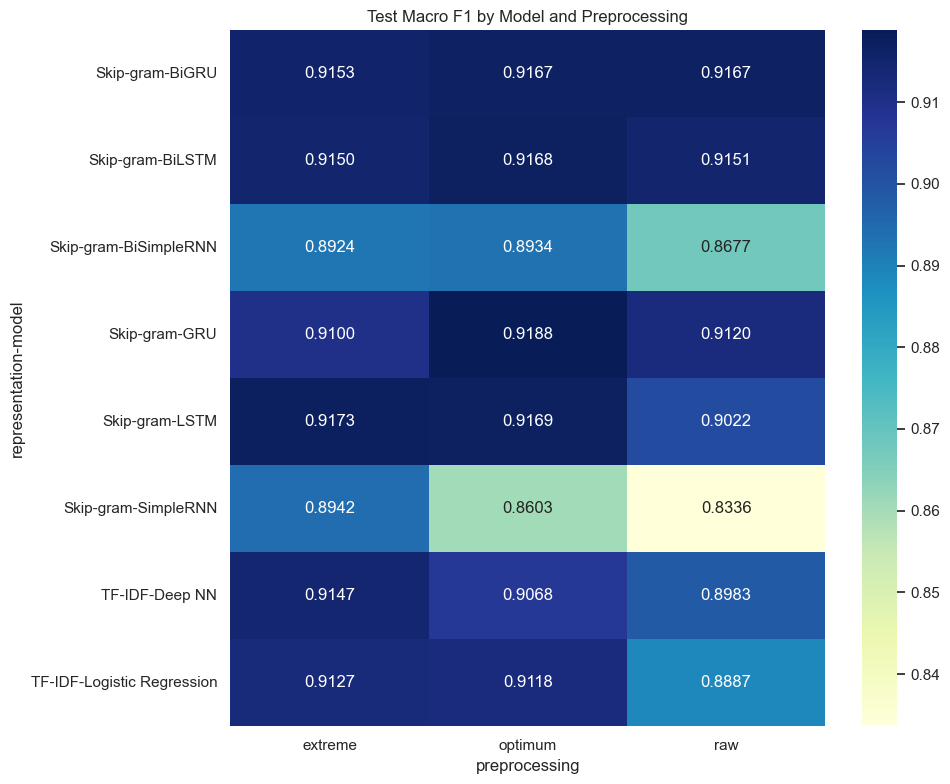

,representation,preprocessing,test_macro_f1,group
3,TF-IDF,extreme,0.913678,TF-IDF | extreme
4,TF-IDF,optimum,0.909319,TF-IDF | optimum
0,Skip-gram,extreme,0.907379,Skip-gram | extreme
1,Skip-gram,optimum,0.903808,Skip-gram | optimum
5,TF-IDF,raw,0.893477,TF-IDF | raw
2,Skip-gram,raw,0.891210,Skip-gram | raw


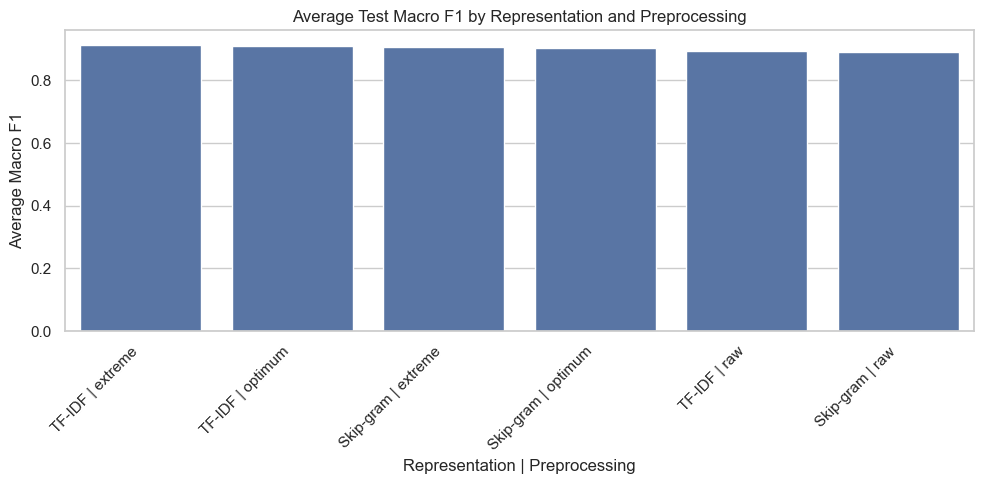

Average macro F1 by preprocessing


,preprocessing,test_macro_f1
0,extreme,0.908954
1,optimum,0.905186
2,raw,0.891777


Average macro F1 by representation


,representation,test_macro_f1
0,TF-IDF,0.905491
1,Skip-gram,0.900799


Average macro F1 by model


,representation,model,test_macro_f1
0,Skip-gram,BiGRU,0.916234
1,Skip-gram,BiLSTM,0.915633
2,Skip-gram,GRU,0.913616
3,Skip-gram,LSTM,0.912108
4,TF-IDF,Deep NN,0.906592
5,TF-IDF,Logistic Regression,0.904391
6,Skip-gram,BiSimpleRNN,0.884495
7,Skip-gram,SimpleRNN,0.862708


In [88]:
results_df = pd.read_csv(RESULTS_PATH)
results_df = results_df.sort_values(
    by=["representation", "test_macro_f1", "test_accuracy"],
    ascending=[True, False, False],
).reset_index(drop=True)

display(results_df[[
    "run_name",
    "preprocessing",
    "representation",
    "model",
    "val_macro_f1",
    "test_macro_f1",
    "test_accuracy",
]])

best_row = results_df.sort_values("test_macro_f1", ascending=False).iloc[0]
worst_row = results_df.sort_values("test_macro_f1", ascending=True).iloc[0]

print("Best run:")
display(best_row.to_frame().T)

print("Worst run:")
display(worst_row.to_frame().T)


pivot_f1 = results_df.pivot_table(
    index=["representation", "model"],
    columns="preprocessing",
    values="test_macro_f1",
)

display(pivot_f1)

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_f1, annot=True, fmt=".4f", cmap="YlGnBu")
plt.title("Test Macro F1 by Model and Preprocessing")
plt.tight_layout()
plt.show()


summary_by_representation = (
    results_df.groupby(["representation", "preprocessing"])["test_macro_f1"]
    .mean()
    .reset_index()
    .sort_values("test_macro_f1", ascending=False)
)

summary_by_representation["group"] = (
    summary_by_representation["representation"] + " | " + summary_by_representation["preprocessing"]
)

display(summary_by_representation)

plt.figure(figsize=(10, 5))
sns.barplot(data=summary_by_representation, x="group", y="test_macro_f1")
plt.title("Average Test Macro F1 by Representation and Preprocessing")
plt.xlabel("Representation | Preprocessing")
plt.ylabel("Average Macro F1")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


best_preprocessing = (
    results_df.groupby("preprocessing")["test_macro_f1"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
best_representation = (
    results_df.groupby("representation")["test_macro_f1"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
best_model_group = (
    results_df.groupby(["representation", "model"])["test_macro_f1"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

print("Average macro F1 by preprocessing")
display(best_preprocessing)

print("Average macro F1 by representation")
display(best_representation)

print("Average macro F1 by model")
display(best_model_group)

### 8.1 Load and Prepare Experiment Results

In [89]:
results_path = PROJECT_DIR / "results_pytorch_cuda" / "experiment_history.csv"
results_df = pd.read_csv(results_path)

acc_source = "test_accuracy" if "test_accuracy" in results_df.columns else "accuracy"
f1_source = "test_macro_f1" if "test_macro_f1" in results_df.columns else "macro_f1"

results_df["accuracy"] = pd.to_numeric(results_df[acc_source], errors="coerce")
results_df["macro_f1"] = pd.to_numeric(results_df[f1_source], errors="coerce")

if "val_accuracy" in results_df.columns:
    results_df["val_accuracy"] = pd.to_numeric(results_df["val_accuracy"], errors="coerce")
if "val_macro_f1" in results_df.columns:
    results_df["val_macro_f1"] = pd.to_numeric(results_df["val_macro_f1"], errors="coerce")

display(results_df.head())
print("Total experiments:", len(results_df))
print(results_df.columns.tolist())

,run_name,preprocessing,representation,model,val_accuracy,val_macro_f1,test_accuracy,test_macro_f1,checkpoint_path,history_path,report_path,confusion_matrix_path,hyperparameters,history_plot_path,accuracy,macro_f1
0,extreme_skipgram_bigru,extreme,Skip-gram,BiGRU,0.941775,0.930614,0.915500,0.915307,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...,"{""cell_type"": ""gru"", ""bidirectional"": true, ""h...",f:\Coding\Projects\440 proj\mnt\data\cse440_pr...,0.915500,0.915307
1,extreme_skipgram_bilstm,extreme,Skip-gram,BiLSTM,0.941075,0.930094,0.915083,0.915049,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...,"{""cell_type"": ""lstm"", ""bidirectional"": true, ""...",f:\Coding\Projects\440 proj\mnt\data\cse440_pr...,0.915083,0.915049
2,extreme_skipgram_bisimplernn,extreme,Skip-gram,BiSimpleRNN,0.916131,0.901533,0.893000,0.892400,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...,"{""cell_type"": ""rnn"", ""bidirectional"": true, ""h...",f:\Coding\Projects\440 proj\mnt\data\cse440_pr...,0.893000,0.892400
3,extreme_skipgram_gru,extreme,Skip-gram,GRU,0.940121,0.928241,0.910250,0.910041,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...,"{""cell_type"": ""gru"", ""bidirectional"": false, ""...",f:\Coding\Projects\440 proj\mnt\data\cse440_pr...,0.910250,0.910041
4,extreme_skipgram_lstm,extreme,Skip-gram,LSTM,0.936748,0.925212,0.917500,0.917259,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...,"{""cell_type"": ""lstm"", ""bidirectional"": false, ...",f:\Coding\Projects\440 proj\mnt\data\cse440_pr...,0.917500,0.917259


Total experiments: 24
['run_name', 'preprocessing', 'representation', 'model', 'val_accuracy', 'val_macro_f1', 'test_accuracy', 'test_macro_f1', 'checkpoint_path', 'history_path', 'report_path', 'confusion_matrix_path', 'hyperparameters', 'history_plot_path', 'accuracy', 'macro_f1']


### 8.2 Main Results Table

In [90]:
base_cols = ["run_name", "preprocessing", "representation", "model", "accuracy", "macro_f1"]
summary_cols = base_cols

extra_cols = [
    c for c in [
        "val_accuracy",
        "val_macro_f1",
        "history_path",
        "report_path",
        "confusion_matrix_path",
        "history_plot_path",
    ]
    if c in results_df.columns
]

results_df = results_df.sort_values(["macro_f1", "accuracy"], ascending=False).reset_index(drop=True)
display(results_df[base_cols + extra_cols])

,run_name,preprocessing,representation,model,accuracy,macro_f1,val_accuracy,val_macro_f1,history_path,report_path,confusion_matrix_path,history_plot_path
0,optimum_skipgram_gru,optimum,Skip-gram,GRU,0.918917,0.918768,0.942794,0.931870,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...
1,extreme_skipgram_lstm,extreme,Skip-gram,LSTM,0.917500,0.917259,0.936748,0.925212,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...
2,optimum_skipgram_lstm,optimum,Skip-gram,LSTM,0.917250,0.916906,0.939166,0.928219,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...
3,optimum_skipgram_bilstm,optimum,Skip-gram,BiLSTM,0.916917,0.916791,0.937003,0.925725,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...
4,raw_skipgram_bigru,raw,Skip-gram,BiGRU,0.916917,0.916712,0.940185,0.929827,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...
5,optimum_skipgram_bigru,optimum,Skip-gram,BiGRU,0.916750,0.916684,0.944639,0.934493,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...
6,extreme_skipgram_bigru,extreme,Skip-gram,BiGRU,0.915500,0.915307,0.941775,0.930614,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...
7,raw_skipgram_bilstm,raw,Skip-gram,BiLSTM,0.915000,0.915059,0.937703,0.927476,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...
8,extreme_skipgram_bilstm,extreme,Skip-gram,BiLSTM,0.915083,0.915049,0.941075,0.930094,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...
9,extreme_tfidf_deep_nn,extreme,TF-IDF,Deep NN,0.914833,0.914667,0.945021,0.933725,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...


### 8.2A Hyperparameter Tuning Log

In [91]:
tuning_cols = [
    c for c in [
        "run_name",
        "preprocessing",
        "representation",
        "model",
        "val_accuracy",
        "val_macro_f1",
        "test_accuracy",
        "test_macro_f1",
        "hyperparameters",
    ]
    if c in results_df.columns
]

display(results_df[tuning_cols])

,run_name,preprocessing,representation,model,val_accuracy,val_macro_f1,test_accuracy,test_macro_f1,hyperparameters
0,optimum_skipgram_gru,optimum,Skip-gram,GRU,0.942794,0.931870,0.918917,0.918768,"{""cell_type"": ""gru"", ""bidirectional"": false, ""..."
1,extreme_skipgram_lstm,extreme,Skip-gram,LSTM,0.936748,0.925212,0.917500,0.917259,"{""cell_type"": ""lstm"", ""bidirectional"": false, ..."
2,optimum_skipgram_lstm,optimum,Skip-gram,LSTM,0.939166,0.928219,0.917250,0.916906,"{""cell_type"": ""lstm"", ""bidirectional"": false, ..."
3,optimum_skipgram_bilstm,optimum,Skip-gram,BiLSTM,0.937003,0.925725,0.916917,0.916791,"{""cell_type"": ""lstm"", ""bidirectional"": true, ""..."
4,raw_skipgram_bigru,raw,Skip-gram,BiGRU,0.940185,0.929827,0.916917,0.916712,"{""cell_type"": ""gru"", ""bidirectional"": true, ""h..."
5,optimum_skipgram_bigru,optimum,Skip-gram,BiGRU,0.944639,0.934493,0.916750,0.916684,"{""cell_type"": ""gru"", ""bidirectional"": true, ""h..."
6,extreme_skipgram_bigru,extreme,Skip-gram,BiGRU,0.941775,0.930614,0.915500,0.915307,"{""cell_type"": ""gru"", ""bidirectional"": true, ""h..."
7,raw_skipgram_bilstm,raw,Skip-gram,BiLSTM,0.937703,0.927476,0.915000,0.915059,"{""cell_type"": ""lstm"", ""bidirectional"": true, ""..."
8,extreme_skipgram_bilstm,extreme,Skip-gram,BiLSTM,0.941075,0.930094,0.915083,0.915049,"{""cell_type"": ""lstm"", ""bidirectional"": true, ""..."
9,extreme_tfidf_deep_nn,extreme,TF-IDF,Deep NN,0.945021,0.933725,0.914833,0.914667,"{""hidden_dims"": [384, 192, 128], ""dropouts"": [..."


### 8.3 Accuracy and Macro F1 Comparison

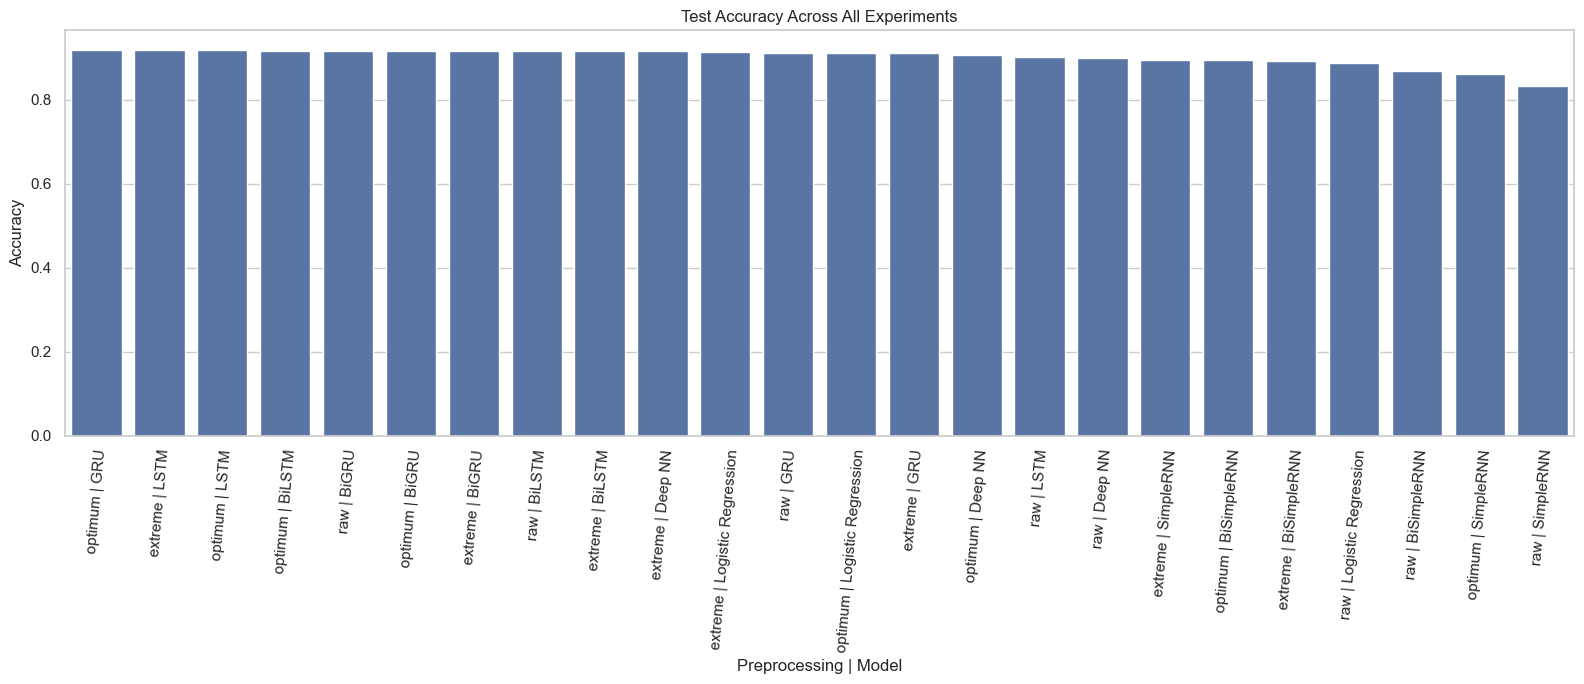

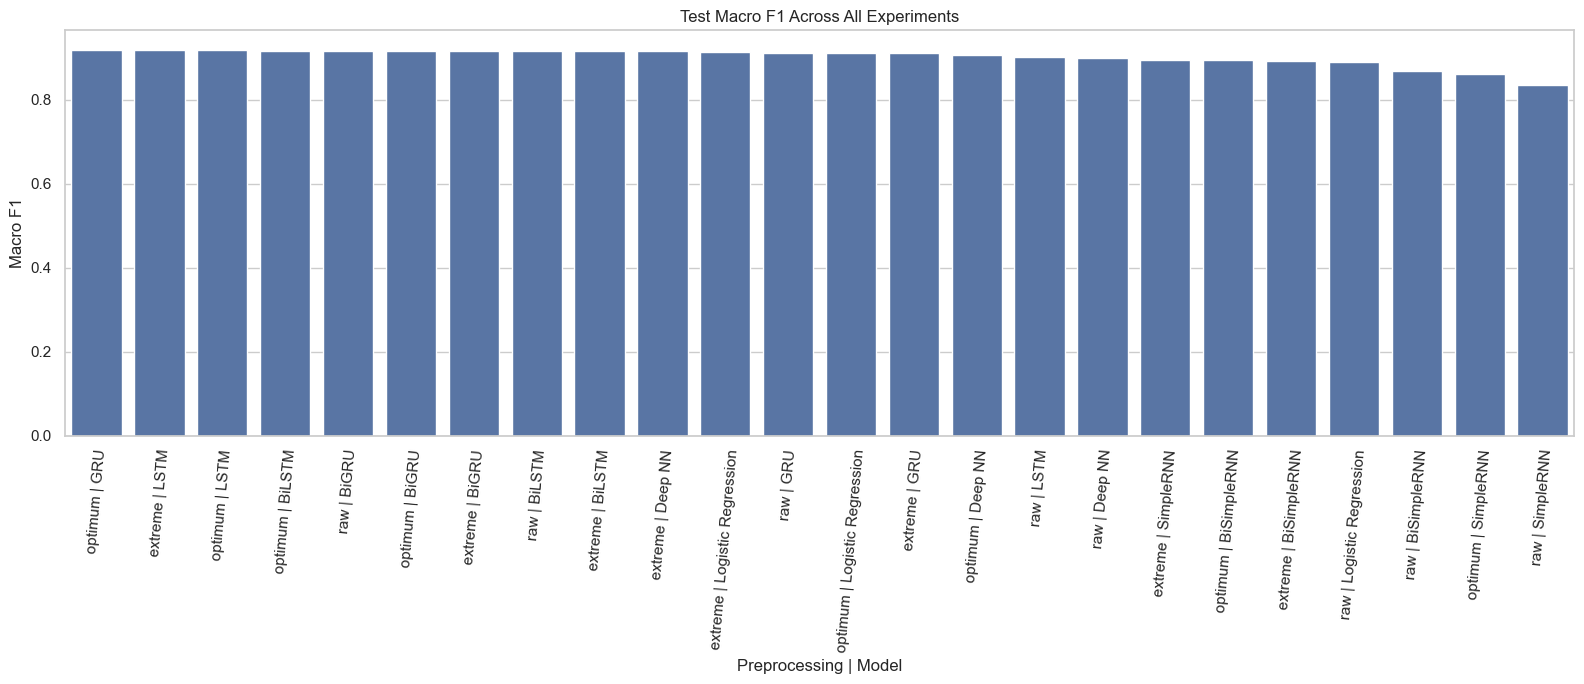

In [92]:
plot_df = results_df.copy()
plot_df["label"] = plot_df["preprocessing"] + " | " + plot_df["model"]

plt.figure(figsize=(16, 7))
sns.barplot(data=plot_df, x="label", y="accuracy")
plt.title("Test Accuracy Across All Experiments")
plt.xlabel("Preprocessing | Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=85)
plt.tight_layout()
plt.show()

plt.figure(figsize=(16, 7))
sns.barplot(data=plot_df, x="label", y="macro_f1")
plt.title("Test Macro F1 Across All Experiments")
plt.xlabel("Preprocessing | Model")
plt.ylabel("Macro F1")
plt.xticks(rotation=85)
plt.tight_layout()
plt.show()

### 8.4 Heatmap Comparison by Model and Preprocessing

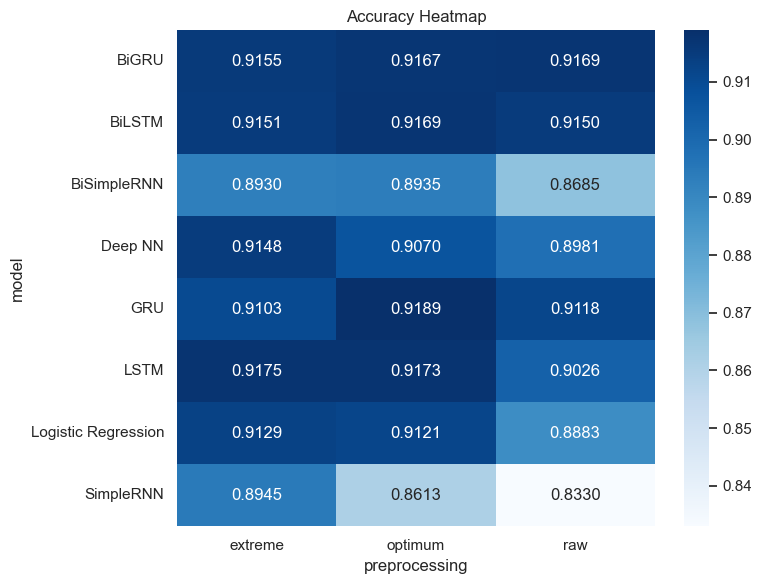

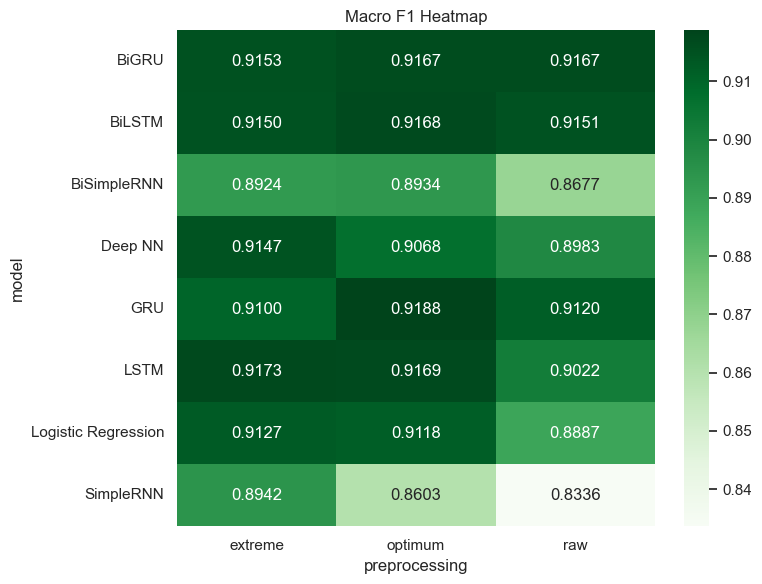

In [93]:
acc_heatmap = results_df.pivot_table(
    index="model",
    columns="preprocessing",
    values="accuracy",
    aggfunc="max"
)

f1_heatmap = results_df.pivot_table(
    index="model",
    columns="preprocessing",
    values="macro_f1",
    aggfunc="max"
)

plt.figure(figsize=(8, 6))
sns.heatmap(acc_heatmap, annot=True, fmt=".4f", cmap="Blues")
plt.title("Accuracy Heatmap")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(f1_heatmap, annot=True, fmt=".4f", cmap="Greens")
plt.title("Macro F1 Heatmap")
plt.tight_layout()
plt.show()

### 8.5 Best and Worst Experiments

In [94]:
best_row = results_df.sort_values(["macro_f1", "accuracy"], ascending=False).iloc[0]
worst_row = results_df.sort_values(["macro_f1", "accuracy"], ascending=True).iloc[0]

best_worst_df = pd.DataFrame([best_row, worst_row])
display(best_worst_df[base_cols + extra_cols])

print("Best run:")
print(best_row["run_name"])

print("\nWorst run:")
print(worst_row["run_name"])

,run_name,preprocessing,representation,model,accuracy,macro_f1,val_accuracy,val_macro_f1,history_path,report_path,confusion_matrix_path,history_plot_path
0,optimum_skipgram_gru,optimum,Skip-gram,GRU,0.918917,0.918768,0.942794,0.931870,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...
23,raw_skipgram_simplernn,raw,Skip-gram,SimpleRNN,0.833000,0.833623,0.839644,0.822564,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...,f:\Coding\Projects\440 proj\mnt\data\cse440_pr...


Best run:
optimum_skipgram_gru

Worst run:
raw_skipgram_simplernn


### 8.6 Best Preprocessing and Best Model Family

In [95]:
best_preprocessing = (
    results_df.groupby("preprocessing")[["accuracy", "macro_f1"]]
    .mean()
    .sort_values(["macro_f1", "accuracy"], ascending=False)
    .reset_index()
)

best_model_family = (
    results_df.groupby("model")[["accuracy", "macro_f1"]]
    .mean()
    .sort_values(["macro_f1", "accuracy"], ascending=False)
    .reset_index()
)

print("Average performance by preprocessing")
display(best_preprocessing)

print("Average performance by model")
display(best_model_family)

Average performance by preprocessing


,preprocessing,accuracy,macro_f1
0,extreme,0.909198,0.908954
1,optimum,0.905469,0.905186
2,raw,0.891781,0.891777


Average performance by model


,model,accuracy,macro_f1
0,BiGRU,0.916389,0.916234
1,BiLSTM,0.915667,0.915633
2,GRU,0.913667,0.913616
3,LSTM,0.912444,0.912108
4,Deep NN,0.906639,0.906592
5,Logistic Regression,0.904444,0.904391
6,BiSimpleRNN,0.885000,0.884495
7,SimpleRNN,0.862944,0.862708


### 8.7 Classification Reports

In [96]:
print("Best run classification report")
display(pd.read_csv(best_row["report_path"], index_col=0))

print("Worst run classification report")
display(pd.read_csv(worst_row["report_path"], index_col=0))

Best run classification report


,precision,recall,f1-score,support
Business,0.914490,0.852000,0.882140,3000.000000
Science and Technology,0.860543,0.940000,0.898518,3000.000000
Sports,0.964814,0.978000,0.971362,3000.000000
World News,0.941115,0.905667,0.923051,3000.000000
accuracy,0.918917,0.918917,0.918917,0.918917
macro avg,0.920241,0.918917,0.918768,12000.000000
weighted avg,0.920241,0.918917,0.918768,12000.000000


Worst run classification report


,precision,recall,f1-score,support
Business,0.687118,0.862333,0.764819,3000.000
Science and Technology,0.897543,0.718333,0.798000,3000.000
Sports,0.918627,0.963333,0.940449,3000.000
World News,0.879464,0.788000,0.831224,3000.000
accuracy,0.833000,0.833000,0.833000,0.833
macro avg,0.845688,0.833000,0.833623,12000.000
weighted avg,0.845688,0.833000,0.833623,12000.000


### 8.8 Confusion Matrices for Best and Worst Runs

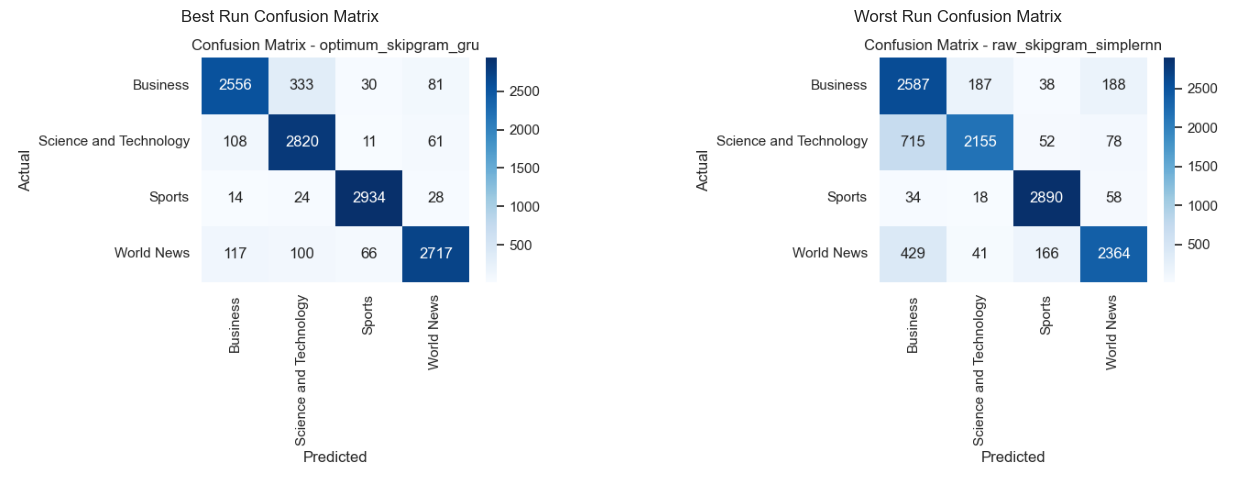

In [97]:
from PIL import Image

cm_col = "confusion_matrix_path" if "confusion_matrix_path" in results_df.columns else None

if cm_col is None:
    print("No saved confusion matrix image path column found in results_df.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, row, title in zip(
        axes,
        [best_row, worst_row],
        ["Best Run Confusion Matrix", "Worst Run Confusion Matrix"]
    ):
        img = Image.open(row[cm_col])
        ax.imshow(img)
        ax.set_title(title)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

### 8.9 Combined Neural Training History

In [98]:
neural_rows = results_df[results_df["history_path"].fillna("") != ""].copy()

all_histories = []
for _, row in neural_rows.iterrows():
    hist_path = Path(row["history_path"])
    if hist_path.exists():
        hist = pd.read_csv(hist_path)
        hist["run_name"] = row["run_name"]
        hist["preprocessing"] = row["preprocessing"]
        hist["representation"] = row["representation"]
        hist["model"] = row["model"]
        all_histories.append(hist)

if all_histories:
    all_histories_df = pd.concat(all_histories, ignore_index=True)
    display(all_histories_df.head())
else:
    all_histories_df = pd.DataFrame()
    print("No neural history files found yet.")

,epoch,train_loss,train_acc,train_f1,val_loss,val_acc,val_f1,run_name,preprocessing,representation,model
0,1,0.373703,0.866095,0.842566,0.253490,0.917213,0.902695,optimum_skipgram_gru,optimum,Skip-gram,GRU
1,2,0.253688,0.916506,0.902386,0.259627,0.913268,0.895835,optimum_skipgram_gru,optimum,Skip-gram,GRU
2,3,0.234277,0.922502,0.909218,0.235486,0.922876,0.909819,optimum_skipgram_gru,optimum,Skip-gram,GRU
3,4,0.219430,0.926938,0.914202,0.216844,0.930003,0.918477,optimum_skipgram_gru,optimum,Skip-gram,GRU
4,5,0.208114,0.930599,0.918428,0.203898,0.932549,0.920807,optimum_skipgram_gru,optimum,Skip-gram,GRU


### 8.10 Full Combined History Plots

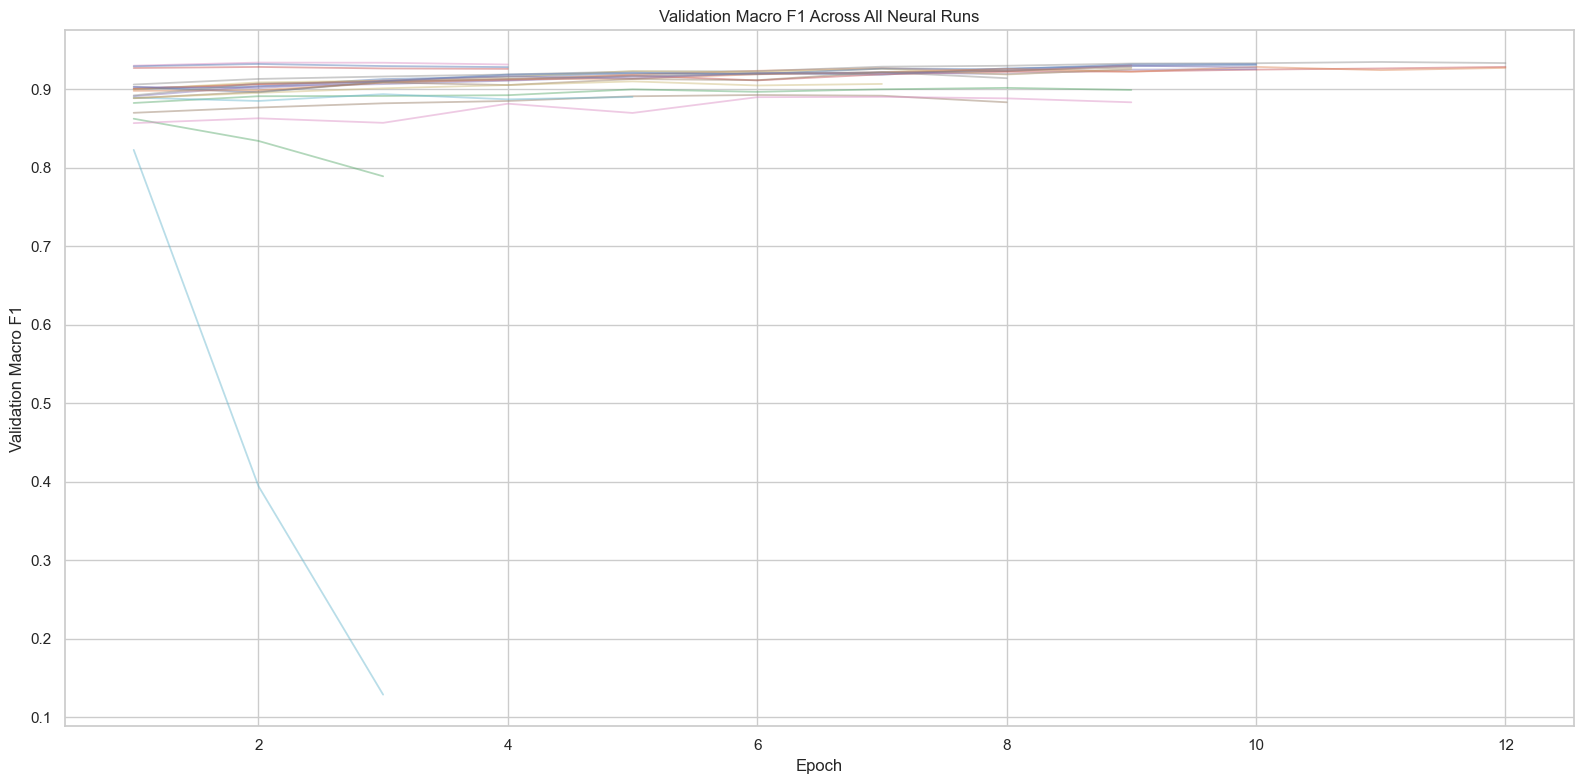

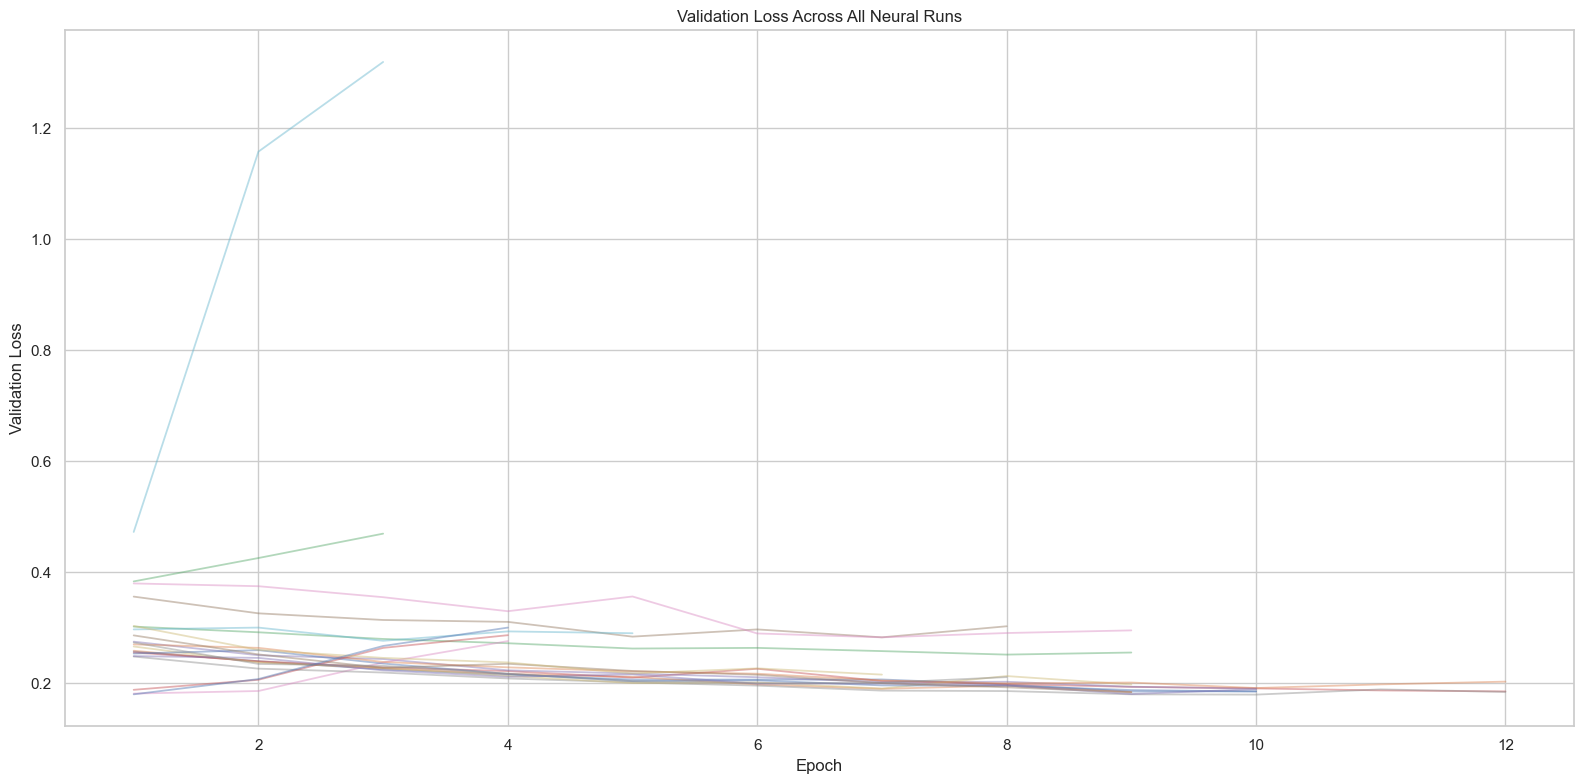

In [99]:
if all_histories_df.empty:
    print("No neural histories available yet.")
else:
    plt.figure(figsize=(16, 8))
    for run_name, grp in all_histories_df.groupby("run_name"):
        if "val_f1" in grp.columns:
            plt.plot(grp["epoch"], grp["val_f1"], alpha=0.45, linewidth=1.3)

    plt.title("Validation Macro F1 Across All Neural Runs")
    plt.xlabel("Epoch")
    plt.ylabel("Validation Macro F1")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(16, 8))
    for run_name, grp in all_histories_df.groupby("run_name"):
        if "val_loss" in grp.columns:
            plt.plot(grp["epoch"], grp["val_loss"], alpha=0.45, linewidth=1.3)

    plt.title("Validation Loss Across All Neural Runs")
    plt.xlabel("Epoch")
    plt.ylabel("Validation Loss")
    plt.tight_layout()
    plt.show()

### 8.11 Average Validation Curves by Model

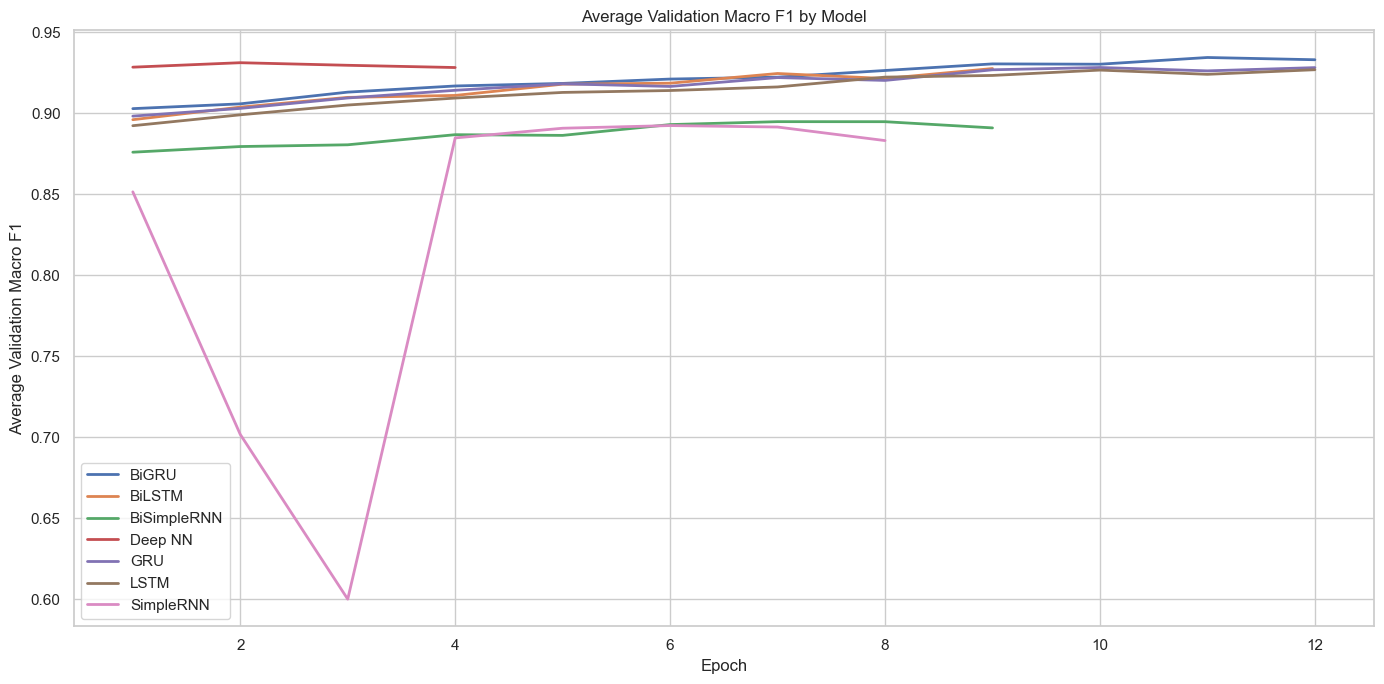

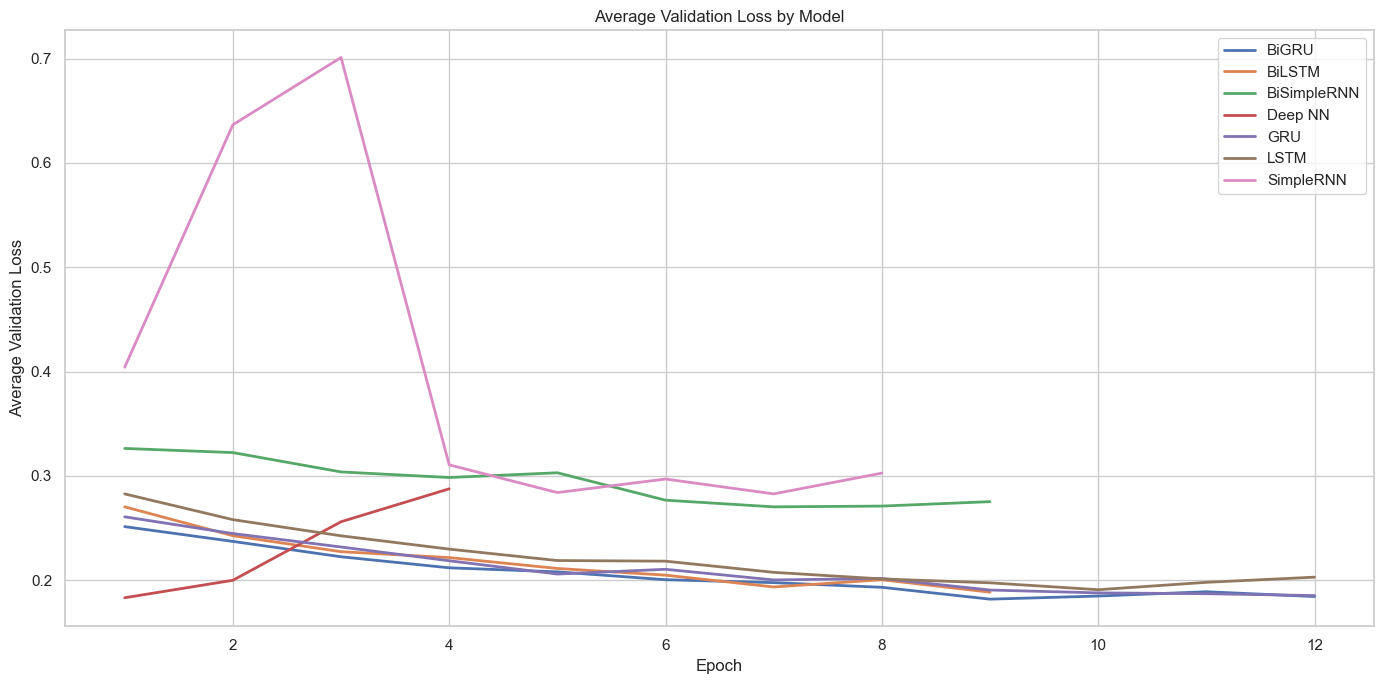

In [100]:
if all_histories_df.empty:
    print("No neural histories available for model-level comparison.")
else:
    if "val_f1" in all_histories_df.columns:
        plt.figure(figsize=(14, 7))
        for model_name, grp in all_histories_df.groupby("model"):
            avg_curve = grp.groupby("epoch")["val_f1"].mean()
            plt.plot(avg_curve.index, avg_curve.values, label=model_name, linewidth=2)

        plt.title("Average Validation Macro F1 by Model")
        plt.xlabel("Epoch")
        plt.ylabel("Average Validation Macro F1")
        plt.legend()
        plt.tight_layout()
        plt.show()

    if "val_loss" in all_histories_df.columns:
        plt.figure(figsize=(14, 7))
        for model_name, grp in all_histories_df.groupby("model"):
            avg_curve = grp.groupby("epoch")["val_loss"].mean()
            plt.plot(avg_curve.index, avg_curve.values, label=model_name, linewidth=2)

        plt.title("Average Validation Loss by Model")
        plt.xlabel("Epoch")
        plt.ylabel("Average Validation Loss")
        plt.legend()
        plt.tight_layout()
        plt.show()

## 9. Inspect Any Saved Neural History

In [101]:
def show_saved_history(run_name: str):
    history_path = HISTORY_DIR / f"{run_name}_history.csv"
    if not history_path.exists():
        print("No history file found for:", run_name)
        return

    history_df = pd.read_csv(history_path)
    display(history_df)
    save_history_plot(history_df, run_name)
    display(history_df.tail())

## 10. Short Conclusion Notes for the Report

After the full run finishes, summarize:
- which preprocessing version worked best overall
- which representation worked best overall
- the best and worst individual runs
- whether aggressive preprocessing helped or hurt the dataset
- how validation performance matched the final test performance
- why the final hyperparameters were kept for each model